In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
current_pwd = os.getcwd()

possible_paths = [
    '/home/export/soheuny/SRFinder/soheun/notebooks', 
    '/home/soheuny/HH4bsim/soheun/notebooks'
]
    
assert os.getcwd() in possible_paths, f"Did you change the path? It should be one of {possible_paths}"
os.chdir("..")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import torch
import tqdm

from plots import hist_events_by_labels
from events_data import EventsData
from fvt_classifier import FvTClassifier
# import LogNorm
from matplotlib.colors import LogNorm
from training_info import TrainingInfo
from attention_classifier import AttentionClassifier
from plots import plot_rewighted_samples_by_model, plot_samples_raw
from dataset import MotherSamples
from events_data import events_from_scdinfo



features = [
    "sym_Jet0_pt", "sym_Jet1_pt", "sym_Jet2_pt", "sym_Jet3_pt",
    "sym_Jet0_eta", "sym_Jet1_eta", "sym_Jet2_eta", "sym_Jet3_eta",
    "sym_Jet0_phi", "sym_Jet1_phi", "sym_Jet2_phi", "sym_Jet3_phi",  
    "sym_Jet0_m", "sym_Jet1_m", "sym_Jet2_m", "sym_Jet3_m",
]

# use tex
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"

plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.titlesize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 15
plt.rcParams["figure.labelsize"] = 20
plt.rcParams["lines.markersize"] = 3

import pandas as pd


df_3b = pd.read_hdf("../events/MG3/dataframes/threeTag_picoAOD.h5")
df_bg4b = pd.read_hdf("../events/MG3/dataframes/fourTag_10x_picoAOD.h5")
df_signal = pd.read_hdf("../events/MG3/dataframes/HH4b_picoAOD.h5")
df_3b["signal"] = False
df_bg4b["signal"] = False
df_signal["signal"] = True
raw_df_list = [df_3b, df_bg4b, df_signal]

In [3]:
_, hparams = TrainingInfo.find(
    {"experiment_name": lambda x: x == "smeared_fvt_training_noise_scale"}, 
    from_metadata=False,
    return_hparams=True
)

0it [00:00, ?it/s]

2181it [00:02, 838.91it/s] 


In [4]:
un, counts = np.unique([hp["dataset"]["seed"] for hp in hparams], return_counts=True)
# un[counts == 2]
un[counts < 9]
# counts
# counts
for seed in un[counts < 9]:
    print(seed)
    existing = [(hp["dataset"]["signal_ratio"], hp["smearing"]["noise_scale"]) for hp in hparams if hp["dataset"]["seed"] == seed]
    print(np.sort(existing))
    


100%|██████████| 60/60 [04:32<00:00,  4.54s/it]
/tmp/ipykernel_313667/2317928158.py:67: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(f"./data/plots/SR_stats_by_noise_scale_signal_ratio={signal_ratio}.pdf", dpi=300)
/home/export/soheuny/.conda/envs/coffea_torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


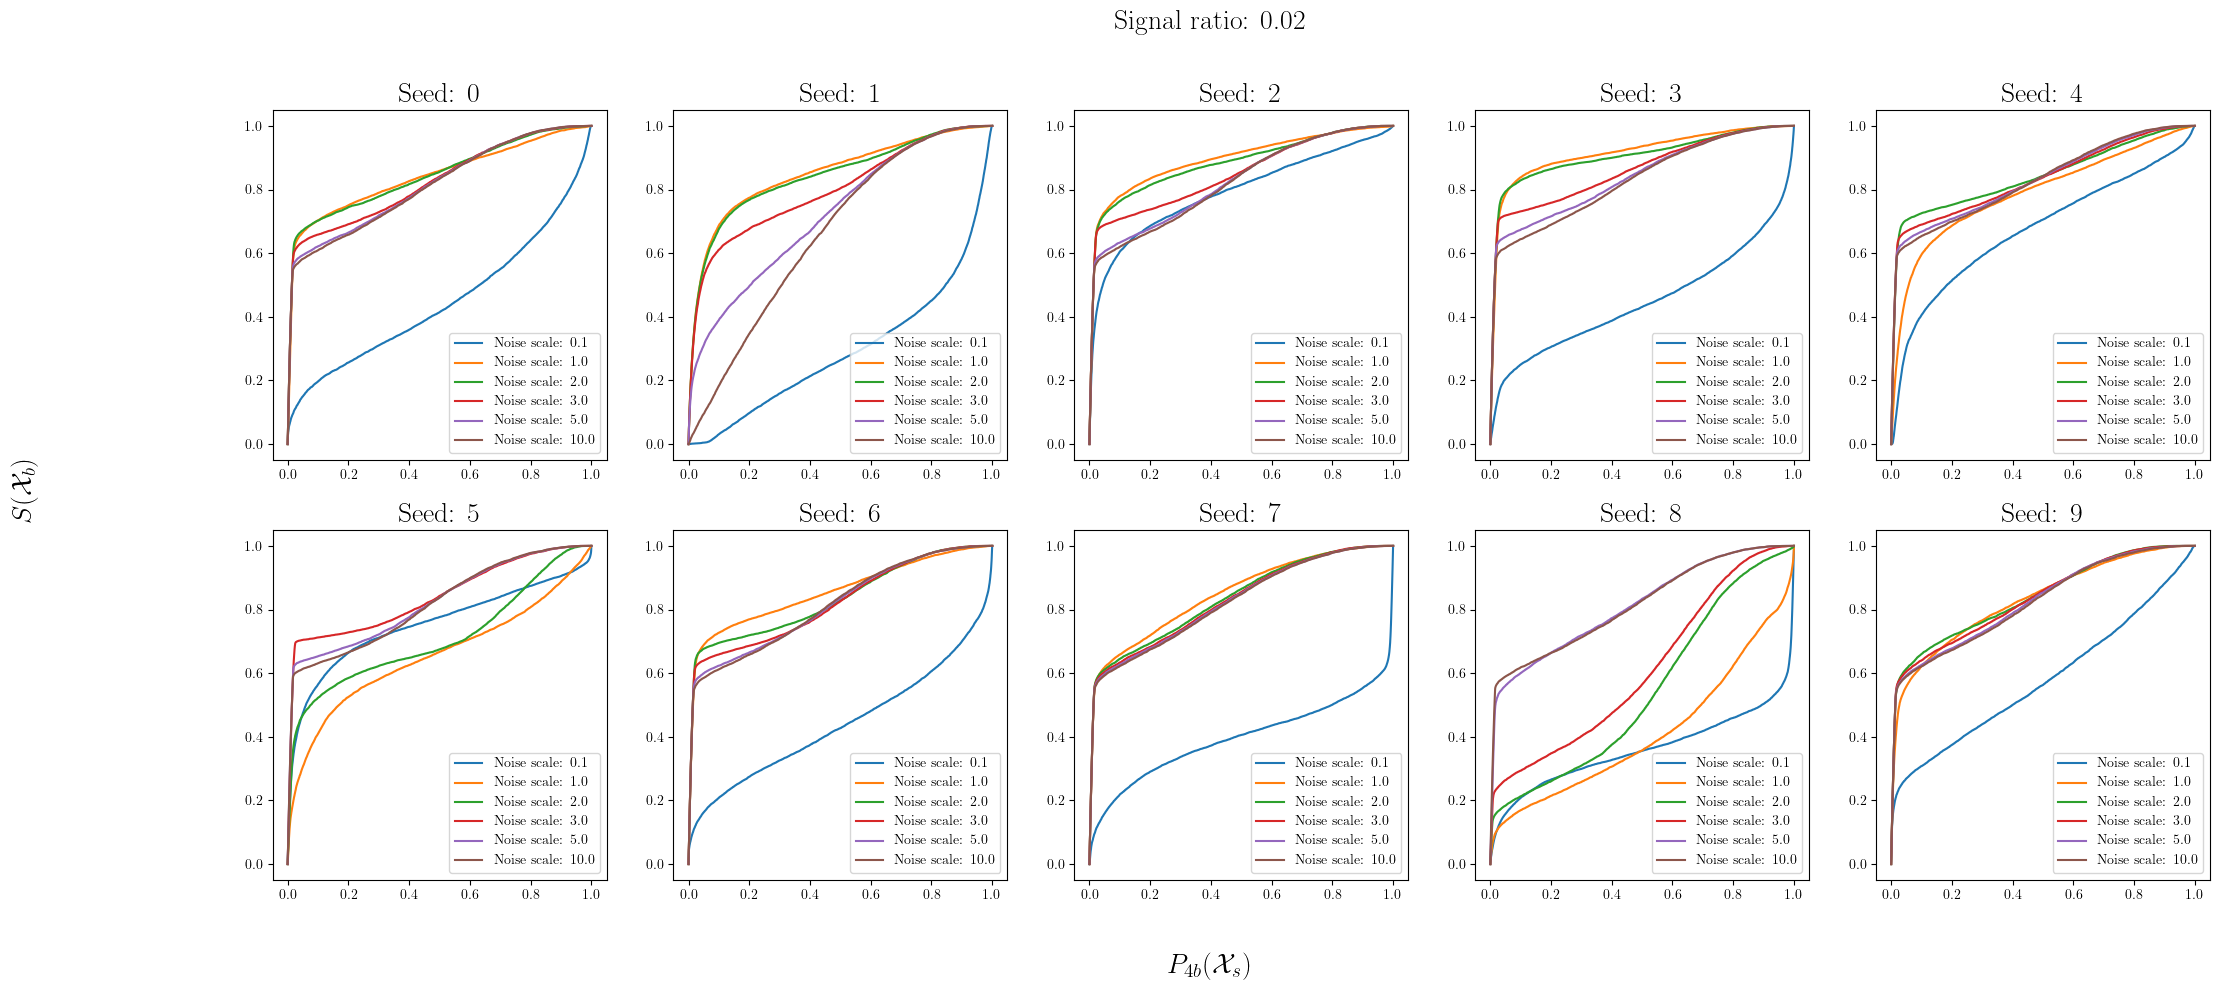

In [65]:
from events_data import get_is_signal
from plots import hist_events_by_labels, plot_sr_stats

signal_filename = "HH4b_picoAOD.h5"
# hparams = TrainingInfo.get_existing_hparams()
# np.unique([hp["experiment_name"] for hp in hparams])

experiment_name = "smeared_fvt_training_noise_scale"
# hparams = [hp for hp in hparams if hp["experiment_name"] == experiment_name]
signal_ratio = 0.02
hparam_filter ={
    "experiment_name": lambda x: x == experiment_name or x == "smeared_fvt_training",
    "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["n_3b"] == 100_0000,
}
hashes, hparams = TrainingInfo.find(hparam_filter, return_hparams=True)
s_ns_hash_tuples = [(hp["dataset"]["seed"], hp["smearing"]["noise_scale"], hash) for hash, hp in zip(hashes, hparams)]
seeds_and_noise_scales = sorted(s_ns_hash_tuples, key=lambda x: (x[0], x[1]))

current_seed = None
unique_seeds = np.unique([seed for seed, _, _ in seeds_and_noise_scales])
ncols = 5
nrows = (len(unique_seeds) + ncols - 1) // ncols
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 5))
fig.supxlabel("$P_{4b}(\mathcal{X}_s)$")
fig.supylabel("$S(\mathcal{X}_b)$")
fig.suptitle(f"Signal ratio: {signal_ratio}")
ax_cnt = -1

for seed, noise_scale, hash in tqdm.tqdm(seeds_and_noise_scales):
    smeared_fvt_tinfo = TrainingInfo.load(hash)
    if seed != current_seed:
        current_seed = seed
        ax_cnt += 1
        current_ax = axs[ax_cnt // ncols, ax_cnt % ncols]
        current_ax.set_title(f"Seed: {seed}")
        # Update base encoder hash
        base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
        base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
        base_fvt_model = base_fvt_tinfo.load_trained_model("best")
        base_fvt_model.eval()
        base_fvt_model.to(torch.device("cuda"))
        base_fvt_model: FvTClassifier
        
        tst_scdinfo = MotherSamples.load(smeared_fvt_tinfo.ms_hash).scdinfo
        tst_scdinfo = tst_scdinfo[~smeared_fvt_tinfo.ms_idx]
        df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
        events_tst = EventsData.from_dataframe(df_tst, features)        
        
        base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
        base_q_repr = base_q_repr.cpu().numpy()
        base_fvt_scores = base_fvt_scores.cpu().numpy()[:, 1]
        base_gamma = base_fvt_scores / (1 - base_fvt_scores)

    smeared_fvt_model = smeared_fvt_tinfo.load_trained_model("best")
    smeared_fvt_model.eval()
    smeared_fvt_model.to(torch.device("cuda"))
    smeared_fvt_model: AttentionClassifier
    
    smeared_fvt_scores = smeared_fvt_model.predict(base_q_repr)[:, 1].cpu().numpy()
    smeared_gamma = smeared_fvt_scores / (1 - smeared_fvt_scores)
    
    SR_stats = np.log(base_gamma / smeared_gamma)
    plot_sr_stats(events_tst, SR_stats, current_ax, label=f"Noise scale: {noise_scale}")    
    
    current_ax.legend(loc="lower right")
# plt.savefig(f"./data/plots/SR_stats_by_noise_scale_signal_ratio={signal_ratio}.pdf", dpi=300)
plt.show()

  0%|          | 0/50 [00:00<?, ?it/s]

Saving Training Info: 241014_200328_003123_VW6c9H
Saving Training Info: 241110_224316_967599_oWiFKE
Saving Training Info: 241110_224503_574039_ZVFIGt
Saving Training Info: 241110_224314_252311_VF013M


  2%|▏         | 1/50 [00:19<16:18, 19.97s/it]

Saving Training Info: 241014_201057_879433_LyuLNC
Saving Training Info: 241110_225049_083932_dMz8vg
Saving Training Info: 241110_225244_100715_hIIvAa
Saving Training Info: 241110_225052_608794_lhBU6Z


  4%|▍         | 2/50 [00:38<15:29, 19.37s/it]

...

 96%|█████████▌| 48/50 [15:15<00:38, 19.32s/it]

Saving Training Info: 241020_164833_013774_wHom5g
Saving Training Info: 241123_091544_097518_qqFpaK
Saving Training Info: 241123_092200_013202_GTWvvg
Saving Training Info: 241123_092738_277806_vpYlFS


 98%|█████████▊| 49/50 [15:34<00:19, 19.21s/it]

Saving Training Info: 241020_165617_137607_UvERN5
Saving Training Info: 241123_093711_470018_k8WYvz
Saving Training Info: 241123_094311_386559_v1tMnE
Saving Training Info: 241123_095138_456526_X6wEfU


100%|██████████| 50/50 [15:53<00:00, 19.08s/it]


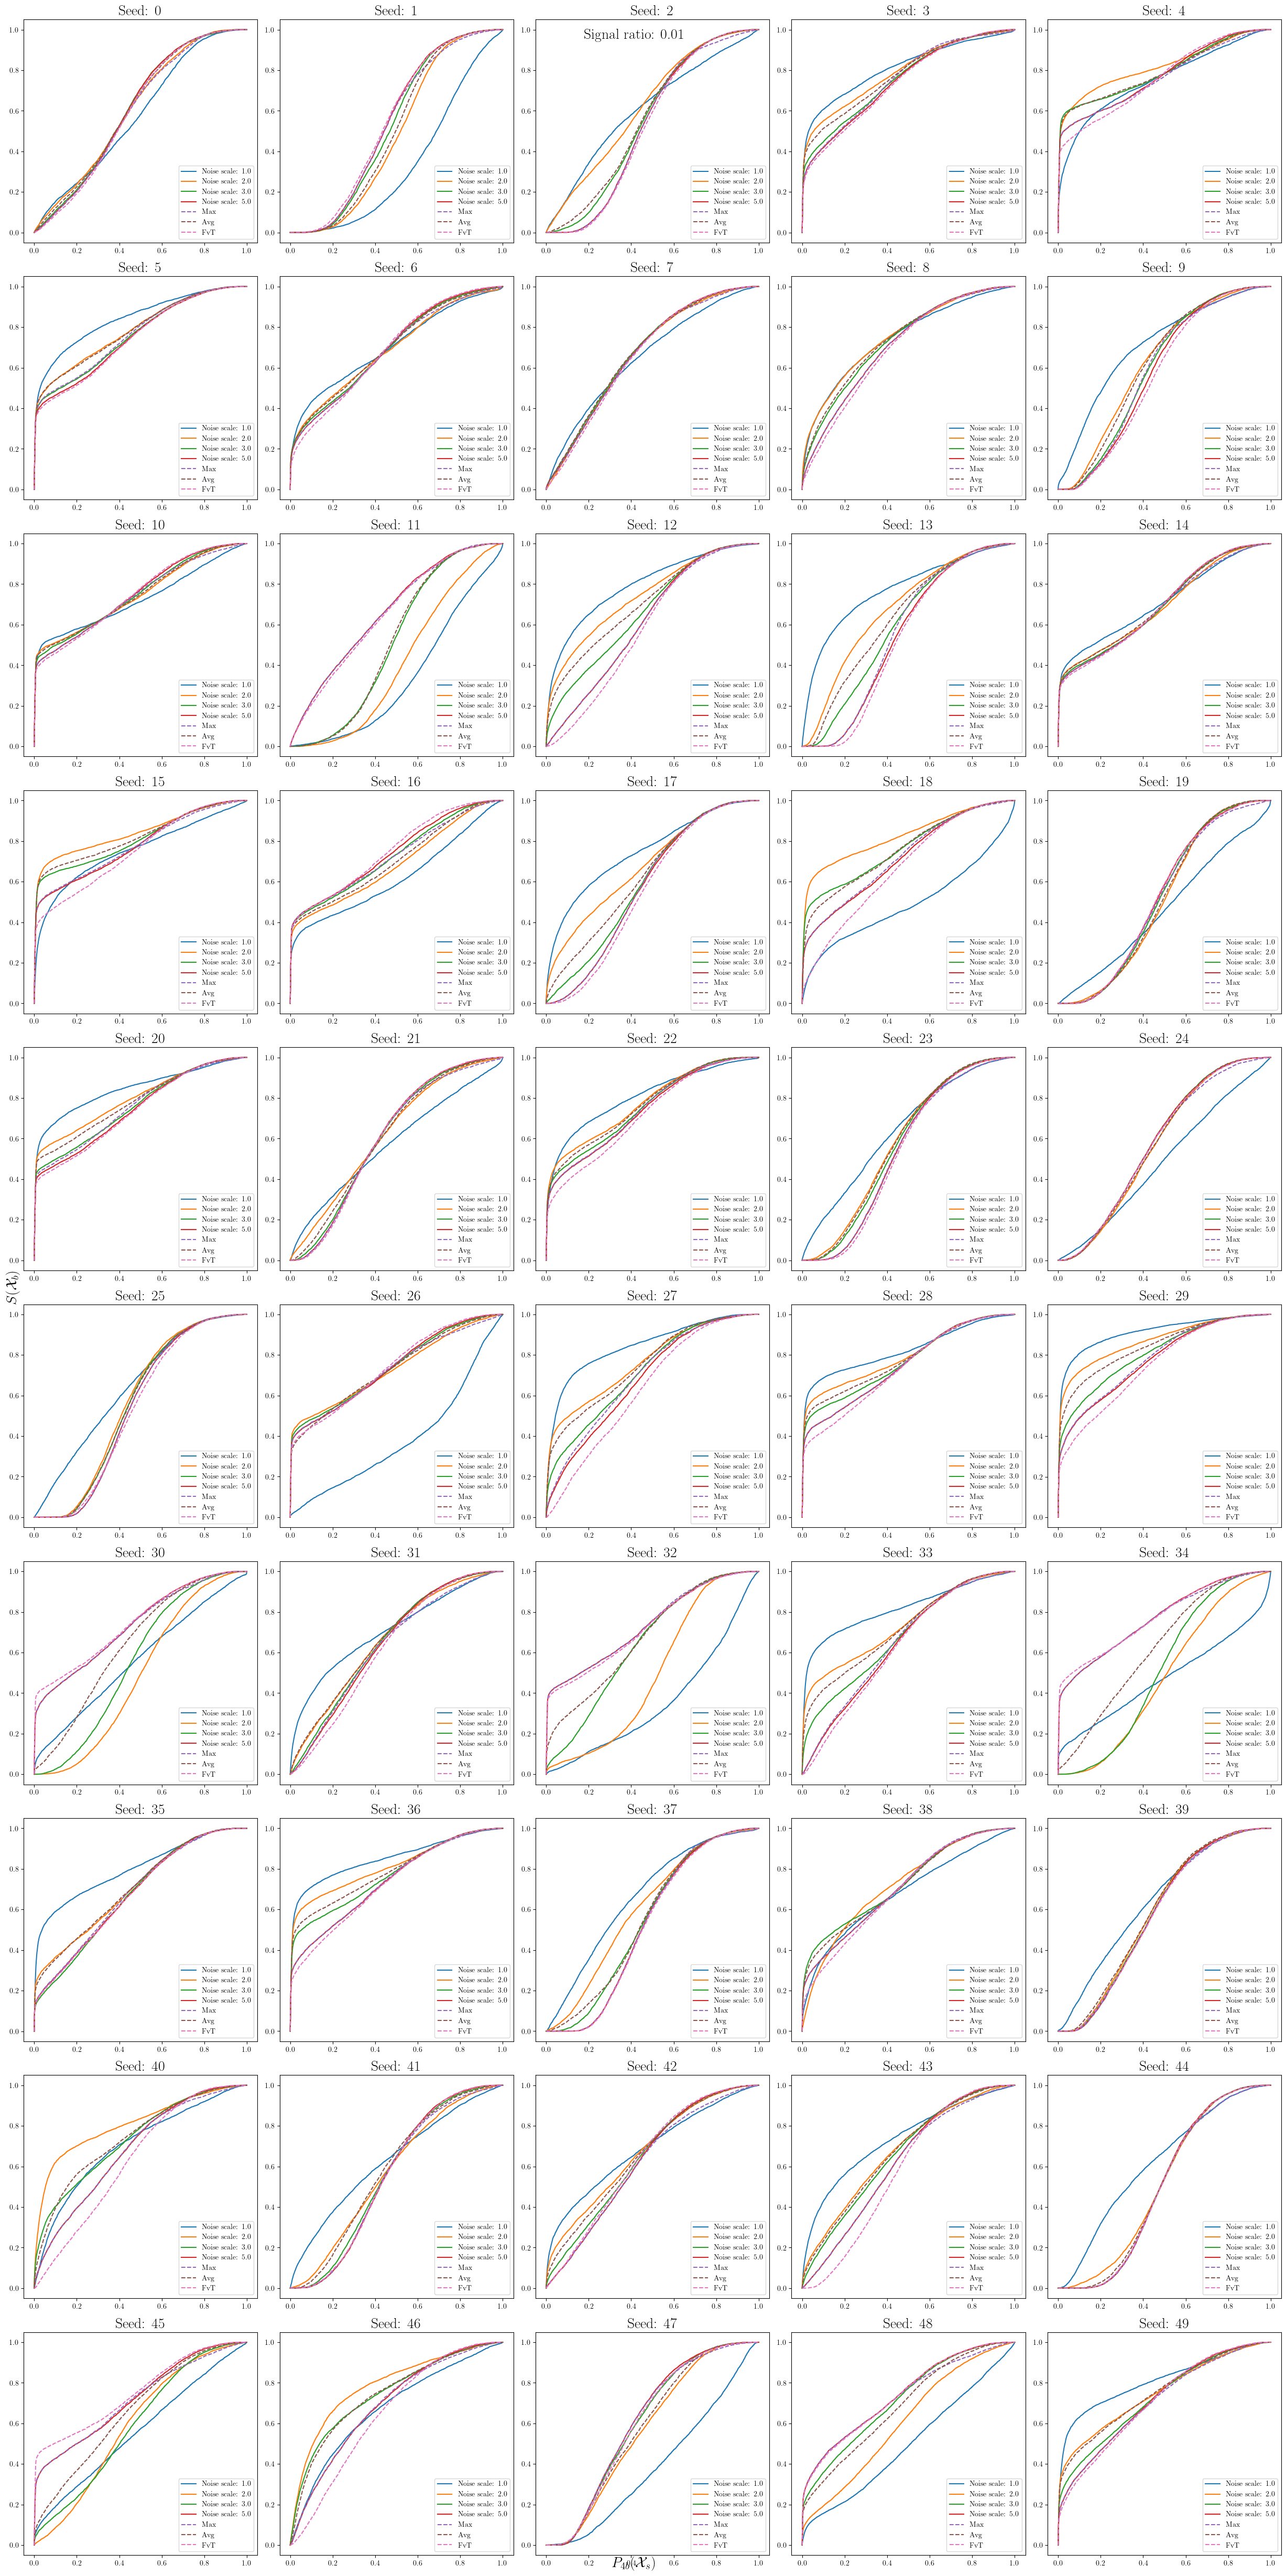

  0%|          | 0/50 [00:00<?, ?it/s]

Saving Training Info: 241014_200332_334400_AKdGiU
Saving Training Info: 241110_224314_253458_cD712z
Saving Training Info: 241110_224458_043216_B2pwJ8
Saving Training Info: 241110_224458_043132_voHDz2


  2%|▏         | 1/50 [00:19<16:02, 19.64s/it]

Saving Training Info: 241014_201058_712347_Xh6vXl
Saving Training Info: 241110_225052_608444_9umPyq
Saving Training Info: 241110_225244_100886_z6qivw
Saving Training Info: 241110_225244_100857_19jdJd


  4%|▍         | 2/50 [00:42<17:13, 21.53s/it]

...

 96%|█████████▌| 48/50 [15:22<00:38, 19.12s/it]

Saving Training Info: 241020_161720_704685_0EJFyv
Saving Training Info: 241123_091750_633997_29bMPm
Saving Training Info: 241123_092456_316732_udO3tU
Saving Training Info: 241123_093151_577840_xx9bkp


 98%|█████████▊| 49/50 [15:41<00:19, 19.16s/it]

Saving Training Info: 241020_162516_990390_RGNOIe
Saving Training Info: 241123_093711_467509_609Vt5
Saving Training Info: 241123_094635_967623_SAZN9E
Saving Training Info: 241123_095215_791262_W8L2y8


100%|██████████| 50/50 [16:01<00:00, 19.22s/it]


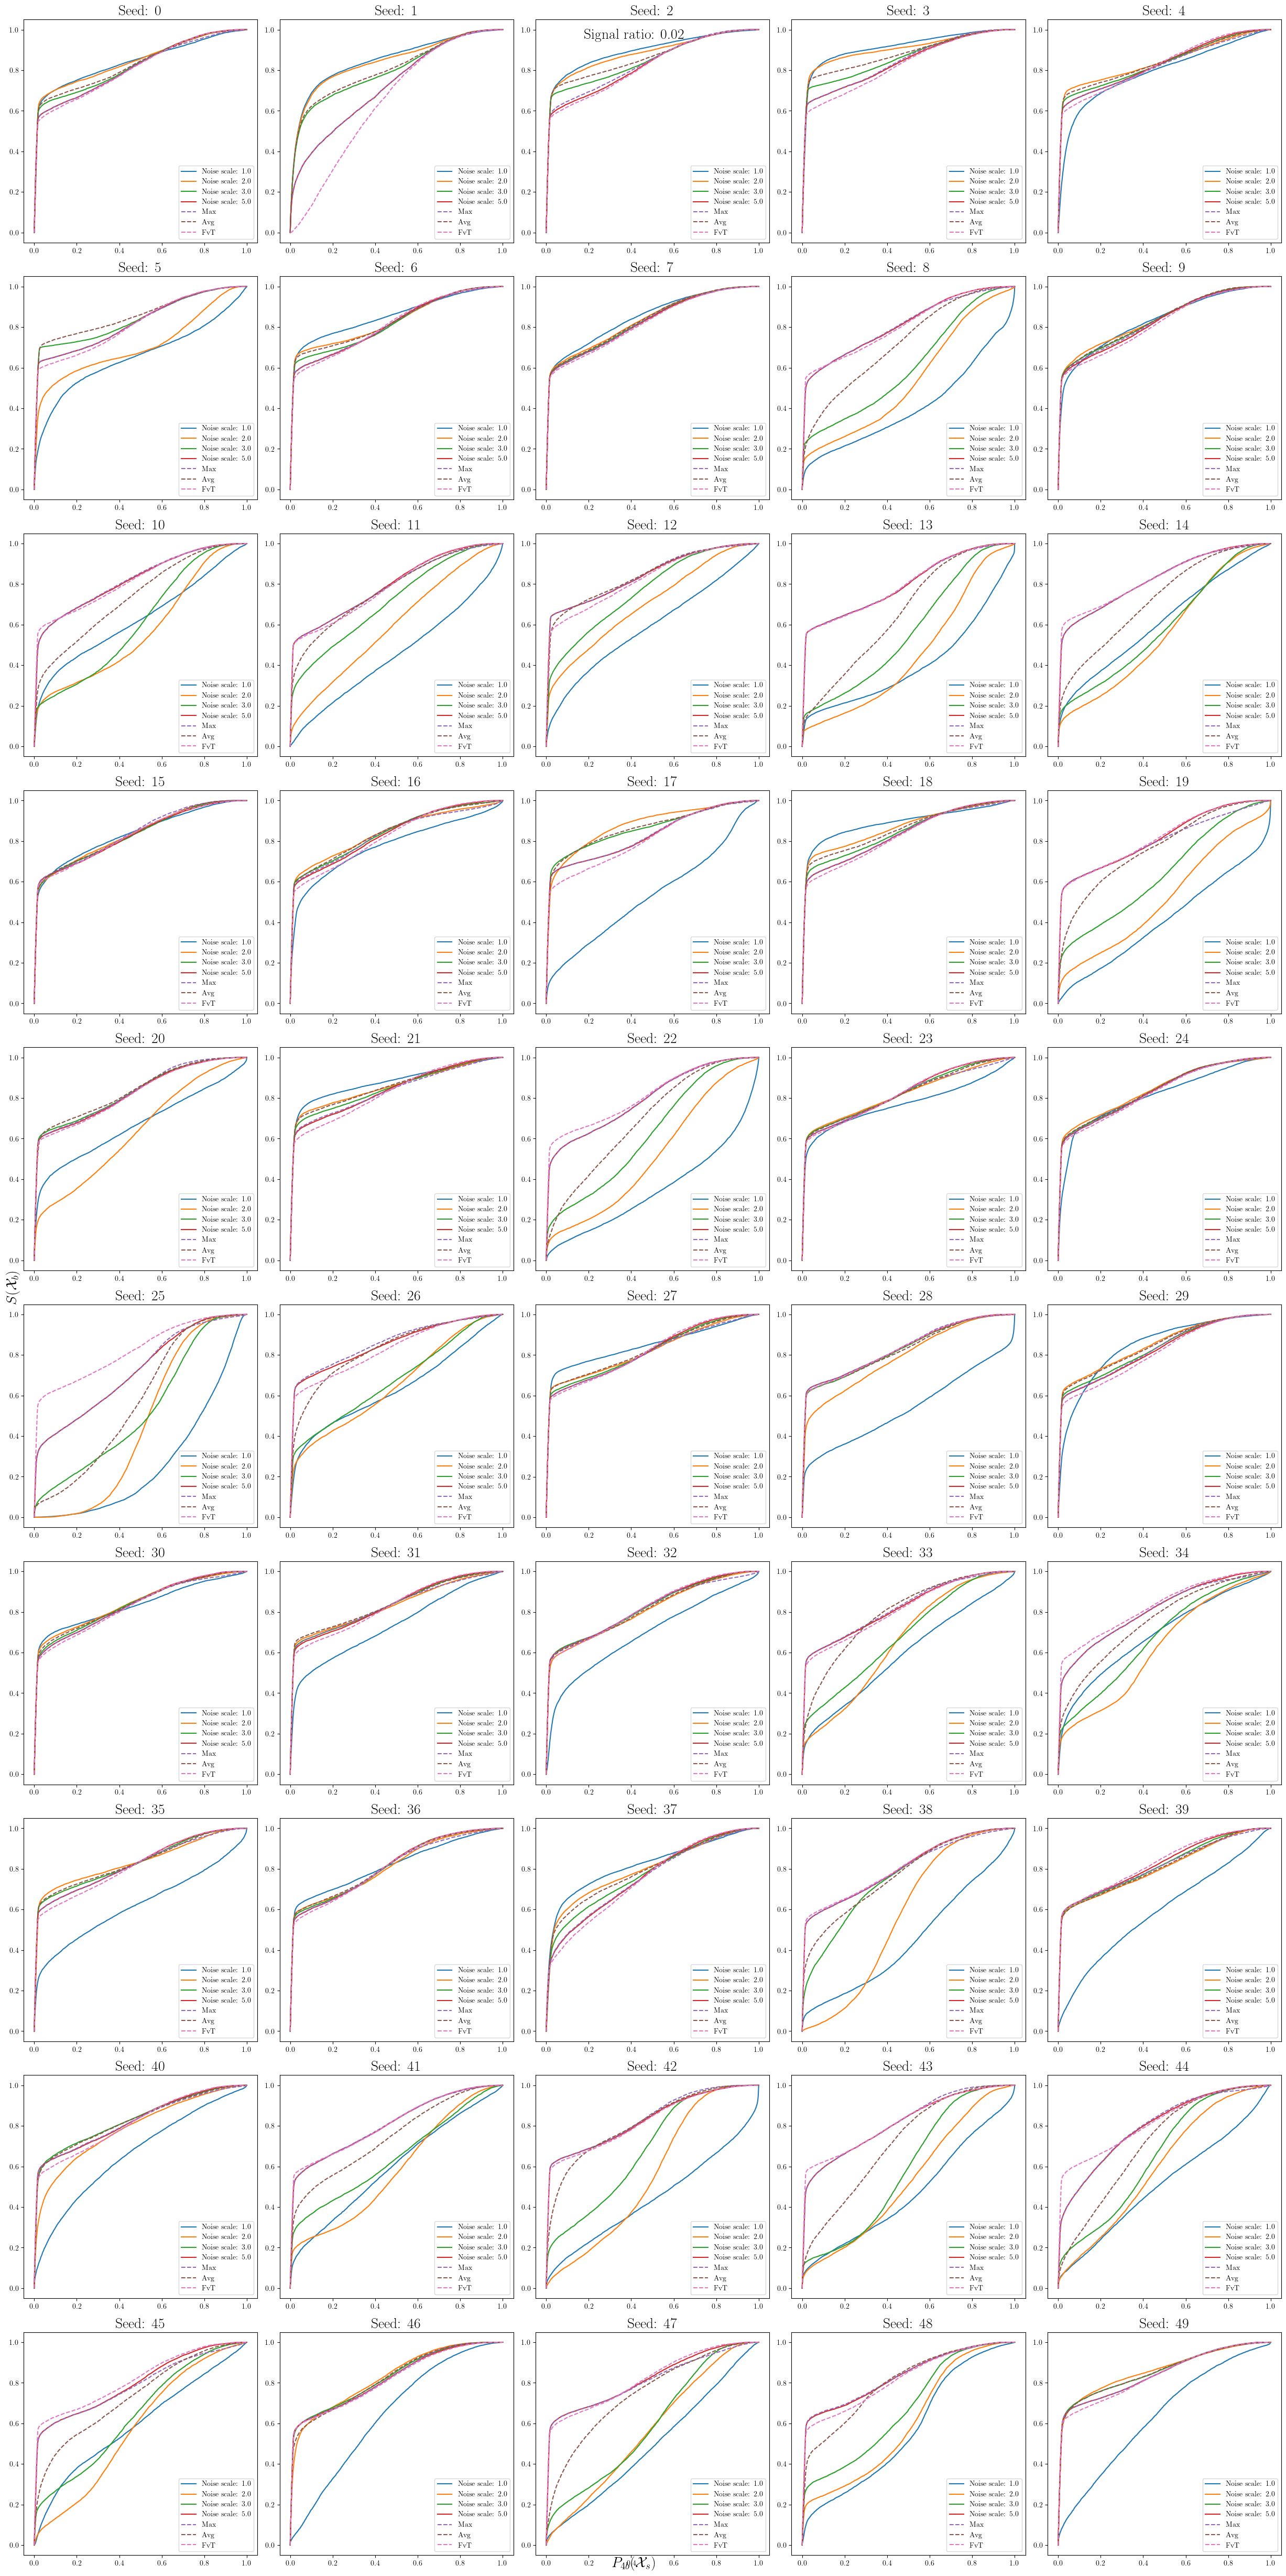

In [5]:
from events_data import get_is_signal
from plots import hist_events_by_labels, plot_sr_stats
from signal_region import get_SR_CR_cut

signal_filename = "HH4b_picoAOD.h5"
# hparams = TrainingInfo.get_existing_hparams()
# np.unique([hp["experiment_name"] for hp in hparams])

experiment_name = "smeared_fvt_training_noise_scale"
# hparams = [hp for hp in hparams if hp["experiment_name"] == experiment_name]

performance_dict = {}
w_4b_ratio_range = np.arange(0, 1.01, 0.01)
noise_scales_to_use = [1.0, 2.0, 3.0, 5.0]

for signal_ratio in [0.01, 0.02]:
    performance_dict[signal_ratio] = {"max": [], "avg": [], "fvt": []}
    
    for noise_scale in noise_scales_to_use:
        performance_dict[signal_ratio][noise_scale] = []
    
    hparam_filter ={
        "experiment_name": lambda x: x == experiment_name or x == "smeared_fvt_training",
        "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["n_3b"] == 100_0000,
    }
    hashes, hparams = TrainingInfo.find(hparam_filter, return_hparams=True)
    s_ns_hash_tuples = [(hp["dataset"]["seed"], hp["smearing"]["noise_scale"], hash) for hash, hp in zip(hashes, hparams)]
    seeds_and_noise_scales = sorted(s_ns_hash_tuples, key=lambda x: (x[0], x[1]))

    unique_seeds = np.unique([seed for seed, _, _ in seeds_and_noise_scales])
    ns_hash_dict = {seed: [] for seed in unique_seeds}

    for seed, noise_scale, hash in seeds_and_noise_scales:
        ns_hash_dict[seed].append((noise_scale, hash))

    ncols = 5
    nrows = (len(unique_seeds) + ncols - 1) // ncols
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 5))
    fig.supxlabel("$P_{4b}(\mathcal{X}_s)$")
    fig.supylabel("$S(\mathcal{X}_b)$")
    fig.suptitle(f"Signal ratio: {signal_ratio}")

    for ax_cnt, seed in enumerate(tqdm.tqdm(unique_seeds)):
        hash = ns_hash_dict[seed][0][1]
        smeared_fvt_tinfo = TrainingInfo.load(hash)
        # Update base encoder hash
        base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
        base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
        base_fvt_model = base_fvt_tinfo.load_trained_model("best")
        base_fvt_model.eval()
        base_fvt_model.to(torch.device("cuda"))
        base_fvt_model: FvTClassifier
        
        tst_scdinfo = MotherSamples.load(smeared_fvt_tinfo.ms_hash).scdinfo
        tst_scdinfo = tst_scdinfo[~smeared_fvt_tinfo.ms_idx]
        df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
        events_tst = EventsData.from_dataframe(df_tst, features)        
        
        base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
        base_q_repr = base_q_repr.cpu().numpy()
        base_fvt_scores = base_fvt_scores.cpu().numpy()[:, 1]
        base_gamma = base_fvt_scores / (1 - base_fvt_scores)
        
        SR_stats_dict = {}
        for noise_scale, hash in ns_hash_dict[seed]:
            if len(noise_scales_to_use) > 0 and noise_scale not in noise_scales_to_use:
                continue
            smeared_fvt_tinfo = TrainingInfo.load(hash)
            smeared_fvt_model = smeared_fvt_tinfo.load_trained_model("best")
            smeared_fvt_model.eval()
            smeared_fvt_model.to(torch.device("cuda"))
            smeared_fvt_model: AttentionClassifier
            
            smeared_fvt_scores = smeared_fvt_model.predict(base_q_repr)[:, 1].cpu().numpy()
            smeared_gamma = smeared_fvt_scores / (1 - smeared_fvt_scores)
            
            SR_stats = np.log(base_gamma / smeared_gamma)
            SR_stats_dict[noise_scale] = SR_stats
            
            smeared_fvt_tinfo.update_aux_info(SR_stats_tst=SR_stats)
            smeared_fvt_tinfo.save()
            
        SR_stats_max = np.max([SR_stats_dict[noise_scale] for noise_scale in SR_stats_dict.keys()], axis=0)
        SR_stats_avg = np.mean([SR_stats_dict[noise_scale] for noise_scale in SR_stats_dict.keys()], axis=0)
        SR_stats_fvt = np.log(base_gamma)
        
        SR_stats_to_compare = [SR_stats_dict[noise_scale] for noise_scale in noise_scales_to_use] + [
            SR_stats_max, SR_stats_avg, SR_stats_fvt]
        labels = [f"Noise scale: {noise_scale}" for noise_scale in noise_scales_to_use] + ["Max", "Avg", "FvT"]
        
        # ncols = 3
        # nrows = (len(SR_stats_to_compare) + ncols - 1) // ncols

        # fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 4, nrows * 4))
        # fig.supxlabel("$P_{4b}(\mathcal{X}_s)$")
        # fig.supylabel("$S(\mathcal{X}_b)$")
        # fig.suptitle(f"Signal ratio: {signal_ratio}, Seed: {seed}")
        # for SR_stats, label, ax in zip(SR_stats_to_compare, labels, axs.flatten()):
        #     SR_cut, CR_cut = get_SR_CR_cut(SR_stats, events_tst, {"4b_in_SR": 0.05, "4b_in_CR": 0.95})
        #     in_SR = SR_stats > SR_cut
        #     in_CR = (SR_stats > CR_cut) & (SR_stats <= SR_cut)
        #     events_tst_CR = events_tst[in_CR]
        #     hist_events_by_labels(events_tst_CR, base_fvt_scores[in_CR], bins=np.linspace(0, 1, 40), ax=ax)
        #     ax.set_title(label)
        #     ax.set_yscale("log")
        # plt.tight_layout()
        # plt.show()
        # plt.close()

        current_ax = axs[ax_cnt // ncols, ax_cnt % ncols]
        current_ax.set_title(f"Seed: {seed}")
        
        for noise_scale in sorted(SR_stats_dict.keys()):
            w_4b_ratio, w_signal_ratio = plot_sr_stats(events_tst, SR_stats_dict[noise_scale], current_ax, label=f"Noise scale: {noise_scale}", return_results=True)
            performance_dict[signal_ratio][noise_scale].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        
        w_4b_ratio, w_signal_ratio = plot_sr_stats(events_tst, SR_stats_max, current_ax, label="Max", linestyle="--", return_results=True)
        performance_dict[signal_ratio]["max"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        
        w_4b_ratio, w_signal_ratio = plot_sr_stats(events_tst, SR_stats_avg, current_ax, label="Avg", linestyle="--", return_results=True)
        performance_dict[signal_ratio]["avg"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        
        w_4b_ratio, w_signal_ratio = plot_sr_stats(events_tst, SR_stats_fvt, current_ax, label="FvT", linestyle="--", return_results=True)
        performance_dict[signal_ratio]["fvt"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        
        current_ax.legend(loc="lower right")
    
    plt.tight_layout()
    plt.savefig(f"./data/plots/SR_stats_by_noise_scale_and_avg_max_signal_ratio={signal_ratio}.pdf", dpi=300)
    plt.show()

In [31]:
# import pickle
# SR_performance_dict = performance_dict
# with open("./data/tmp/SR_performance_dict.pkl", "wb") as f:
#     pickle.dump(SR_performance_dict, f)

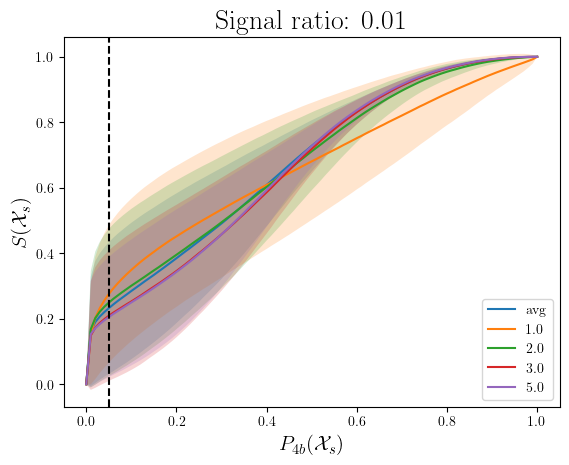

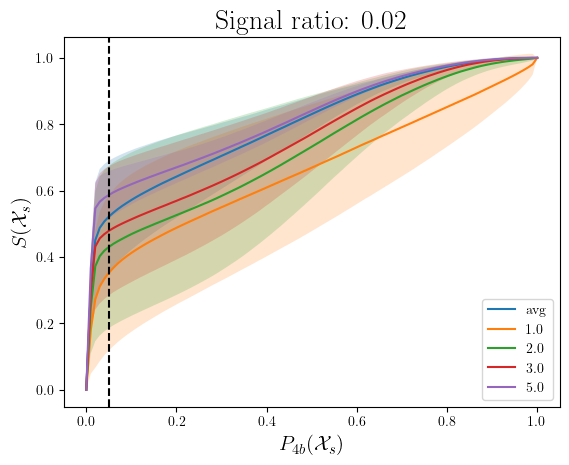

In [6]:
import pickle
SR_performance_dict = pickle.load(open("./data/tmp/SR_performance_dict.pkl", "rb"))

for signal_ratio in SR_performance_dict.keys():
    # for key in SR_performance_dict[signal_ratio].keys():
    for key in ["avg", 1.0, 2.0, 3.0, 5.0]:
        mean = np.mean(SR_performance_dict[signal_ratio][key], axis=0)
        std = np.std(SR_performance_dict[signal_ratio][key], axis=0)
        plt.plot(w_4b_ratio_range, mean, label=f"{key}")
        plt.fill_between(w_4b_ratio_range, mean - std, mean + std, alpha=0.2)
    plt.title(f"Signal ratio: {signal_ratio}")
    plt.xlabel("$P_{4b}(\mathcal{X}_s)$")
    plt.ylabel("$S(\mathcal{X}_s)$")
    plt.axvline(0.05, color="black", linestyle="--")
    plt.legend()
    plt.show()


In [3]:
from events_data import get_is_signal
from plots import hist_events_by_labels, get_weights_by_sr_stats

signal_filename = "HH4b_picoAOD.h5"
experiment_name = "smeared_fvt_training_noise_scale"

performance_dict = {}
w_4b_ratio_range = np.arange(0, 1.01, 0.01)
noise_scales_to_use = [1.0, 2.0, 3.0, 5.0]

SR_stats_dict = {}
for signal_ratio in [0.01, 0.02]:
    SR_stats_dict[signal_ratio] = {seed: {} for seed in range(50)}
    
    hparam_filter ={
        "experiment_name": lambda x: x == experiment_name or x == "smeared_fvt_training",
        "dataset": lambda x: x["signal_ratio"] == signal_ratio and x["n_3b"] == 100_0000,
    }
    hashes, hparams = TrainingInfo.find(hparam_filter, return_hparams=True)
    s_ns_hash_tuples = [(hp["dataset"]["seed"], hp["smearing"]["noise_scale"], hash) for hash, hp in zip(hashes, hparams)]
    seeds_and_noise_scales = sorted(s_ns_hash_tuples, key=lambda x: (x[0], x[1]))

    unique_seeds = np.unique([seed for seed, _, _ in seeds_and_noise_scales])
    ns_hash_dict = {seed: [] for seed in unique_seeds}

    for seed, noise_scale, hash in seeds_and_noise_scales:
        ns_hash_dict[seed].append((noise_scale, hash))

    for seed in tqdm.tqdm(unique_seeds):
        for noise_scale, hash in ns_hash_dict[seed]:
            if len(noise_scales_to_use) > 0 and noise_scale not in noise_scales_to_use:
                continue
            smeared_fvt_tinfo = TrainingInfo.load(hash)
            SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
            SR_stats_dict[signal_ratio][seed][noise_scale] = SR_stats


100%|██████████| 50/50 [00:00<00:00, 124.18it/s]


In [4]:
events_tst_dict = {}
for signal_ratio in [0.01, 0.02]:
    events_tst_dict[signal_ratio] = {}
    for seed in tqdm.tqdm(range(50)):
        hparam_filter = {
            "experiment_name": "smeared_fvt_training",
            "dataset": lambda x: x["seed"] == seed and x["n_3b"] == 100_0000 and x["signal_ratio"] == signal_ratio,
        }
        hashes = TrainingInfo.find(hparam_filter)
        assert len(hashes) == 1
        hash = hashes[0]
        smeared_fvt_tinfo = TrainingInfo.load(hash)
        msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
        tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
        df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
        events_tst = EventsData.from_dataframe(df_tst, features)
        
        events_tst_dict[signal_ratio][seed] = events_tst

  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [01:04<00:00,  1.29s/it]


In [9]:
from itertools import cycle
import plotly.graph_objects as go

ns_123 = [1.0, 2.0, 3.0]
ns_1235 = [1.0, 2.0, 3.0, 5.0]
ns_135 = [1.0, 3.0, 5.0]
ns_15 = [1.0, 5.0]
w_4b_ratio_range = np.arange(0, 1.01, 0.01)
seeds = range(50)

for signal_ratio in [0.01, 0.02]:
    w_signal_ratio_dict = {
    noise_scale: [] for noise_scale in ns_1235}
    w_signal_ratio_dict.update({
        "max_123": [],
        "avg_123": [],
        "max_135": [],
        "avg_135": [],
        "max_1235": [],
        "avg_1235": [],
        "max_15": [],
        "avg_15": []
        })
    for seed in tqdm.tqdm(seeds):
        events_tst = events_tst_dict[signal_ratio][seed]
        SR_stats = SR_stats_dict[signal_ratio][seed]
        SR_stats_avg_123 = np.mean([SR_stats[noise_scale] for noise_scale in ns_123], axis=0)
        SR_stats_max_123 = np.max([SR_stats[noise_scale] for noise_scale in ns_123], axis=0)
        SR_stats_avg_135 = np.mean([SR_stats[noise_scale] for noise_scale in ns_135], axis=0)
        SR_stats_max_135 = np.max([SR_stats[noise_scale] for noise_scale in ns_135], axis=0)
        SR_stats_avg_1235 = np.mean([SR_stats[noise_scale] for noise_scale in ns_1235], axis=0)
        SR_stats_max_1235 = np.max([SR_stats[noise_scale] for noise_scale in ns_1235], axis=0)
        SR_stats_avg_15 = np.mean([SR_stats[noise_scale] for noise_scale in ns_15], axis=0)
        SR_stats_max_15 = np.max([SR_stats[noise_scale] for noise_scale in ns_15], axis=0)
        
        for noise_scale in ns_1235:
            w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats[noise_scale])
            w_signal_ratio_dict[noise_scale].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
            
        w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_avg_123)
        w_signal_ratio_dict["avg_123"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_max_123)
        w_signal_ratio_dict["max_123"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        
        w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_avg_135)
        w_signal_ratio_dict["avg_135"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_max_135)
        w_signal_ratio_dict["max_135"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        
        w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_avg_1235)
        w_signal_ratio_dict["avg_1235"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_max_1235)
        w_signal_ratio_dict["max_1235"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        
        w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_avg_15)
        w_signal_ratio_dict["avg_15"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        w_4b_ratio, w_signal_ratio = get_weights_by_sr_stats(events_tst, SR_stats_max_15)
        w_signal_ratio_dict["max_15"].append(np.interp(w_4b_ratio_range, w_4b_ratio, w_signal_ratio))
        
    fig = go.Figure()
    colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    labels = [f"Noise scale: {noise_scale}" for noise_scale in ns_1235] + [
        "Avg. over 1, 2, 3",
        "Max over 1, 2, 3",
        "Avg. over 1, 3, 5",
        "Max over 1, 3, 5",
        "Avg. over 1, 2, 3, 5",
        "Max over 1, 2, 3, 5",
        "Avg. over 1, 5",
        "Max over 1, 5"
    ]
    idxs = ns_1235 + ["avg_123", "max_123", "avg_135", "max_135", "avg_1235", "max_1235", "avg_15", "max_15"]
    
    for color, idx, label in zip(cycle(colors), idxs, labels):
        mean_values = np.mean(w_signal_ratio_dict[idx], axis=0)
        std_values = np.std(w_signal_ratio_dict[idx], axis=0)
        fig.add_trace(go.Scatter(
            x=w_4b_ratio_range, 
            y=mean_values, 
            mode='lines', 
            name=label,
            legendgroup=label,
            line=dict(color=color, dash="solid" if idx in ns_1235 else "dash")
        ))
        fig.add_trace(go.Scatter(
            x=np.concatenate([w_4b_ratio_range, w_4b_ratio_range[::-1]]),
            y=np.concatenate([mean_values - std_values, (mean_values + std_values)[::-1]]),
            fill='toself',
            fillcolor=color,
            name=label,
            legendgroup=label,
            opacity=0.3,
            mode='none'
        ))
    fig.add_trace(go.Scatter(
        x=[0.0, 1.0],
        y=[0.0, 1.0],
        mode='lines',
        line=dict(color="black", dash="dash"), 
        name="y = x"
    ))
    fig.update_layout(
        title=f"Signal Ratio vs 4b Ratio, Signal ratio: {signal_ratio}",
        xaxis_title="4b Ratio",
        yaxis_title="Signal Ratio",
        legend_title="Legend",
        autosize=False,
        width=800,
        height=500,
    )
    fig.write_html(f"./data/plots/SR_vs_4b_ratio_signal_ratio={signal_ratio}.html")
    fig.show()


100%|██████████| 50/50 [01:22<00:00,  1.65s/it]


100%|██████████| 50/50 [01:22<00:00,  1.64s/it]


In [3]:
# import pickle
# from itertools import product

# from correct_systematic_error import get_histograms
# from events_data import get_is_signal
# from signal_region import get_SR_CR_cut
# from utils import get_quantiles_with_weights
# seeds = np.arange(50)
# nbins_list = [2**i for i in range(7)]
# experiment_name = "CR_fvt_training_v2"
# bins_mode = "quantile"
# signal_filename = "HH4b_picoAOD.h5"
# n_3b = 100_0000
# nbins_list = [2**i for i in range(7)]

# hists_dict = {(signal_ratio, seed): {} for signal_ratio, seed in product([0.0, 0.01, 0.02], seeds)}
# pull_arrays_before_correction = {}

# for signal_ratio in [0.0, 0.01, 0.02]:
#     for seed in tqdm.tqdm(seeds):
#         hparam_filter = {
#             "experiment_name": experiment_name,
#             "dataset": lambda x: all([x["seed"] == seed, 
#                                 x["n_3b"] == n_3b, 
#                                 x["signal_ratio"] == signal_ratio]),
#             "aux_info_step": 3, 
#             "model": "FvTClassifier"
#         }
#         hashes = TrainingInfo.find(hparam_filter)
#         assert len(hashes) == 1
        
#         hash = hashes[0]
#         CR_fvt_tinfo = TrainingInfo.load(hash)
        
        
#         CR_fvt_tinfo = TrainingInfo.load(hashes[0])
#         base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]
#         base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
#         smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
#         smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)

#         base_fvt_model = base_fvt_tinfo.load_trained_model(
#             CR_fvt_tinfo.hparams["encoder_mode"]
#         )
#         base_fvt_model.eval()
#         base_fvt_model.to(torch.device("cuda"))
#         base_fvt_model: FvTClassifier

#         smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
#             CR_fvt_tinfo.hparams["encoder_mode"]
#         )
#         smeared_fvt_model.eval()
#         smeared_fvt_model.to(torch.device("cuda"))
#         smeared_fvt_model: AttentionClassifier

#         # Use the same mother samples and exclude ones used for training base & smeared FvT model
#         msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
#         tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
#         train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
#         df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
#         df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
#         events_train = EventsData.from_dataframe(df_train, features)
#         df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
#         df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
#         events_tst = EventsData.from_dataframe(df_tst, features)
        
#         SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
#         SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
#         SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])
        
#         SR_idx = SR_stats > SR_cut
#         CR_idx = (SR_stats > CR_cut) & (SR_stats <= SR_cut)
#         events_tst_SR = events_tst[SR_idx]
#         SR_stats_SR = SR_stats[SR_idx]
        
#         SR_train_idx = SR_stats_train > SR_cut
#         events_train_SR = events_train[SR_train_idx]
#         SR_stats_train_SR = SR_stats_train[SR_train_idx]

        
#         CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
#         CR_fvt_model.eval()
#         CR_fvt_model.to(torch.device("cuda"))
#         CR_fvt_model: FvTClassifier
        
#         fvt_scores_SR = CR_fvt_model.predict(events_tst_SR.X_torch)[:, 1].detach().cpu().numpy()
#         reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
#         reweights_SR = np.where(events_tst_SR.is_4b, 1, reweights_SR)
        
#         fvt_scores_SR_train = CR_fvt_model.predict(events_train_SR.X_torch)[:, 1].detach().cpu().numpy()
#         reweights_SR_train = fvt_scores_SR_train / (1 - fvt_scores_SR_train)
#         reweights_SR_train = np.where(events_train_SR.is_4b, 1, reweights_SR_train)
        
#         for nbins in nbins_list:
#             SR_bins = get_quantiles_with_weights(SR_stats_train_SR[events_train_SR.is_3b], 
#                                                 (reweights_SR_train * events_train_SR.weights)[events_train_SR.is_3b], 
#                                                 np.linspace(0, 1, nbins + 1))
#             hists = get_histograms(events_tst_SR, SR_stats_SR, SR_bins, reweights_SR)
#             hists_dict[(signal_ratio, seed)][nbins] = hists
            
# pull_arrays_before_correction = {(signal_ratio, nbins): [] for signal_ratio, nbins in product([0.0, 0.01, 0.02], nbins_list)}

# for signal_ratio, seed in tqdm.tqdm(product([0.0, 0.01, 0.02], seeds)):
#     for nbins in nbins_list:
#         hist_3b_rw = hists_dict[(signal_ratio, seed)][nbins]["3b_rw"]
#         hist_3b_sq = hists_dict[(signal_ratio, seed)][nbins]["3b_sq"]
#         hist_4b = hists_dict[(signal_ratio, seed)][nbins]["4b"]
#         hist_4b_sq = hists_dict[(signal_ratio, seed)][nbins]["4b_sq"]
#         hist_diff = hist_4b - hist_3b_rw
#         hist_var = hist_3b_sq + hist_4b_sq
#         pull = hist_diff / np.sqrt(hist_var)
#         pull_arrays_before_correction[(signal_ratio, nbins)].append(pull)
        
# pull_arrays_before_correction = {k: np.array(v) for k, v in pull_arrays_before_correction.items()}

# with open("./data/tmp/pull_arrays_before_correction.pkl", "wb") as f:
#     pickle.dump(pull_arrays_before_correction, f)

In [4]:
# from correct_systematic_error import constrained_linear_fit, get_histograms
# from utils import get_quantiles_with_weights
# from events_data import get_is_signal
# from signal_region import get_SR_CR_cut
# from scipy import stats

# slope_min = -0.0
# slope_max = 0.0
# intercept_min = -np.inf
# intercept_max = np.inf
# signal_filename = "HH4b_picoAOD.h5"
# experiment_name = "CR_fvt_training_v2"
# n_3b = 100_0000

# seeds = np.arange(50)
# nbins_list = [2**i for i in range(2, 3)]

# signal_ratio_in_SR = {0.01: [], 0.02: []}
# for signal_ratio in [0.01, 0.02]:
#     for seed in tqdm.tqdm(seeds):
#         hparam_filter = {
#             "experiment_name": experiment_name,
#             "dataset": lambda x: all([x["seed"] == seed, 
#                                 x["n_3b"] == n_3b, 
#                                 x["signal_ratio"] == signal_ratio]),
#             "aux_info_step": 3, 
#             "model": "FvTClassifier"
#         }
#         hashes = TrainingInfo.find(hparam_filter)
#         assert len(hashes) == 1
        
#         CR_fvt_tinfo = TrainingInfo.load(hashes[0])
#         base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]
#         base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
#         smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
#         smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)

#         base_fvt_model = base_fvt_tinfo.load_trained_model(
#             CR_fvt_tinfo.hparams["encoder_mode"]
#         )
#         base_fvt_model.eval()
#         base_fvt_model.to(torch.device("cuda"))
#         base_fvt_model: FvTClassifier

#         smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
#             CR_fvt_tinfo.hparams["encoder_mode"]
#         )
#         smeared_fvt_model.eval()
#         smeared_fvt_model.to(torch.device("cuda"))
#         smeared_fvt_model: AttentionClassifier

#         # Use the same mother samples and exclude ones used for training base & smeared FvT model
#         msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
#         tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
#         train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
#         df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
#         df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
#         events_train = EventsData.from_dataframe(df_train, features)
#         df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
#         df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
#         events_tst = EventsData.from_dataframe(df_tst, features)
        
#         SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
#         SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
#         SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])

#         # base_fvt_preds = base_fvt_model.predict(events_tst.X_torch).cpu().numpy()[:, 1]
        
#         # bins = np.linspace(0, 1, 40)
#         # fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
#         # hist_events_by_labels(events_tst, base_fvt_preds, bins=bins, ax=ax[0])
#         # ax[0].set_xlabel("FvT score")
#         # ax[0].set_ylabel("Number of events")
        
#         # bins = np.linspace(np.min(SR_stats), np.max(SR_stats), 40)
#         # hist_events_by_labels(events_tst, SR_stats, bins=bins, ax=ax[1])
#         # ax[1].set_xlabel("SR stats")
#         # ax[1].set_ylabel("Number of events")
        
#         # plt.show()
#         # plt.close(fig)
        
#         in_SR = SR_stats > SR_cut
#         # events_tst[in_SR].total_weight_signal / events_tst[in_SR].total_weight_4b
        
#         signal_ratio_in_SR[signal_ratio].append(
#             events_tst[in_SR].total_weight_signal / events_tst[in_SR].total_weight_4b
#         )
        
    
# with open("./data/tmp/signal_ratio_in_SR.pkl", "wb") as f:
#     pickle.dump(signal_ratio_in_SR, f)


In [67]:
import pickle
from scipy import stats

pull_arrays_dict = pickle.load(open("./data/tmp/pull_arrays_dict.pkl", "rb"))
pull_arrays_before_correction = pickle.load(open("./data/tmp/pull_arrays_before_correction.pkl", "rb"))
signal_ratio_in_SR = pickle.load(open("./data/tmp/signal_ratio_in_SR.pkl", "rb"))

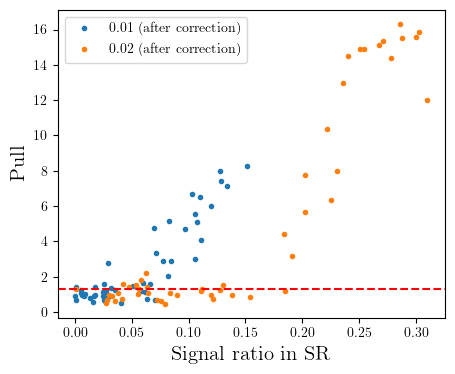

In [6]:
from scipy import stats

n_test_bins = 8
signal_ratio = 0.01

sig_level = 0.05
rej_cut = stats.chi2.ppf(1 - sig_level, df=n_test_bins - 1)
rej_cut = np.sqrt(rej_cut / n_test_bins)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))    
for signal_ratio in [0.01, 0.02]:
    sr_in_SR = signal_ratio_in_SR[signal_ratio]
    mean_pull = np.sqrt(np.mean(pull_arrays_dict[(0.0, 0.0, -np.inf, np.inf)][(signal_ratio, n_test_bins)]**2, axis=1))
    mean_pull_bfc = np.sqrt(np.mean(pull_arrays_before_correction[(signal_ratio, n_test_bins)]**2, axis=1))

    ax.plot(sr_in_SR, mean_pull, "o", label=f"{signal_ratio} (after correction)")
    # ax.plot(sr_in_SR, mean_pull_bfc, "o", label=f"{signal_ratio} (before correction)")
ax.axhline(rej_cut, color="red", linestyle="--")
ax.legend()
ax.set_xlabel("Signal ratio in SR")
ax.set_ylabel("Pull")
plt.show()


Correction is not the main reason that reduces the pull (= power)


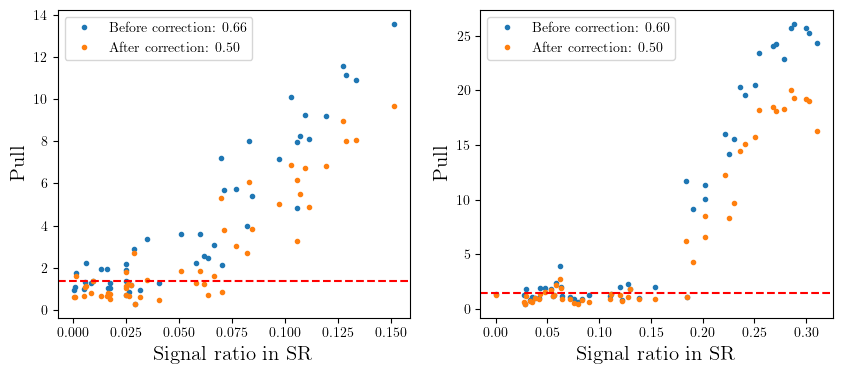

In [7]:
print("Correction is not the main reason that reduces the pull (= power)")

sig_level = 0.05
n_test_bins = 4
signal_ratio = 0.01
rej_cut = stats.chi2.ppf(1 - sig_level, df=n_test_bins - 1)
rej_cut = np.sqrt(rej_cut / n_test_bins)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
for i, signal_ratio in enumerate([0.01, 0.02]):
    sr_in_SR = signal_ratio_in_SR[signal_ratio]
    mean_pull = np.sqrt(np.mean(pull_arrays_dict[(0.0, 0.0, -np.inf, np.inf)][(signal_ratio, n_test_bins)]**2, axis=1))
    mean_pull_bfc = np.sqrt(np.mean(pull_arrays_before_correction[(signal_ratio, n_test_bins)]**2, axis=1))
    
    

    axs[i].plot(sr_in_SR, mean_pull_bfc, "o", label=f"Before correction: {np.mean(mean_pull_bfc > rej_cut):.2f}")
    axs[i].plot(sr_in_SR, mean_pull, "o", label=f"After correction: {np.mean(mean_pull > rej_cut):.2f}")
    axs[i].axhline(rej_cut, color="red", linestyle="--")
    axs[i].set_xlabel("Signal ratio in SR")
    axs[i].set_ylabel("Pull")
    axs[i].legend()
plt.show()


In [8]:
# from correct_systematic_error import get_histograms

# signal_ratio = 0.02
# n_test_bins = 4
# n_CR_bins = 20
# sr_in_SR = np.array(signal_ratio_in_SR[signal_ratio])
# mean_pull = np.sqrt(np.mean(pull_arrays_dict[(0.0, 0.0, -np.inf, np.inf)][(signal_ratio, n_test_bins)]**2, axis=1))
# peculiar_seeds = (mean_pull < rej_cut) & (sr_in_SR > 0.1)
# peculiar_seeds = np.arange(50)[peculiar_seeds]


# for seed in peculiar_seeds:
#     hparam_filter = {
#         "experiment_name": experiment_name,
#         "dataset": lambda x: all([x["seed"] == seed, x["n_3b"] == n_3b, x["signal_ratio"] == signal_ratio]),
#         "aux_info_step": 3, 
#         "model": "FvTClassifier"
#     }
#     hashes = TrainingInfo.find(hparam_filter)
#     assert len(hashes) == 1
#     CR_fvt_tinfo = TrainingInfo.load(hashes[0])
#     base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]
#     base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
#     smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
#     smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)

#     base_fvt_model = base_fvt_tinfo.load_trained_model(
#         CR_fvt_tinfo.hparams["encoder_mode"]
#     )
#     base_fvt_model.eval()
#     base_fvt_model.to(torch.device("cuda"))
#     base_fvt_model: FvTClassifier

#     smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
#         CR_fvt_tinfo.hparams["encoder_mode"]
#     )
#     smeared_fvt_model.eval()
#     smeared_fvt_model.to(torch.device("cuda"))
#     smeared_fvt_model: AttentionClassifier

#     # Use the same mother samples and exclude ones used for training base & smeared FvT model
#     msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
#     tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
#     train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
#     df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
#     df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
#     events_train = EventsData.from_dataframe(df_train, features)
#     df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
#     df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
#     events_tst = EventsData.from_dataframe(df_tst, features)
    
#     SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
#     SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
#     SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])
    
#     SR_idx = SR_stats > SR_cut
#     CR_idx = (SR_stats > CR_cut) & (SR_stats <= SR_cut)
#     events_tst_SR = events_tst[SR_idx]
#     events_tst_CR = events_tst[CR_idx]
#     SR_stats_SR = SR_stats[SR_idx]
#     SR_stats_CR = SR_stats[CR_idx]
    
#     events_train_SR = events_train[SR_stats_train > SR_cut]
#     SR_stats_train_SR = SR_stats_train[SR_stats_train > SR_cut]
    
#     CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
#     CR_fvt_model.eval()
#     CR_fvt_model.to(torch.device("cuda"))

#     CR_fvt_model: FvTClassifier
#     CR_fvt_scores = CR_fvt_model.predict(events_tst.X_torch)[:, 1].detach().cpu().numpy()
            
#     fvt_scores_SR = CR_fvt_scores[SR_idx]
#     reweights_SR = fvt_scores_SR / (1 - fvt_scores_SR)
#     reweights_SR = np.where(events_tst_SR.is_4b, 1, reweights_SR)
    
#     fvt_scores_CR = CR_fvt_scores[CR_idx]
#     reweights_CR = fvt_scores_CR / (1 - fvt_scores_CR)
#     reweights_CR = np.where(events_tst_CR.is_4b, 1, reweights_CR)

#     fvt_scores_SR_train = CR_fvt_model.predict(events_train_SR.X_torch)[:, 1].detach().cpu().numpy()
#     reweights_SR_train = fvt_scores_SR_train / (1 - fvt_scores_SR_train)
#     reweights_SR_train = np.where(events_train_SR.is_4b, 1, reweights_SR_train)


#     SR_bins = get_quantiles_with_weights(SR_stats_train_SR[events_train_SR.is_3b], 
#                                         (reweights_SR_train * events_train_SR.weights)[events_train_SR.is_3b], 
#                                         np.linspace(0, 1, n_test_bins + 1))
    
#     CR_bins = get_quantiles_with_weights(SR_stats_CR[events_tst_CR.is_3b], 
#                                         (reweights_CR * events_tst_CR.weights)[events_tst_CR.is_3b], 
#                                         np.linspace(0, 1, n_CR_bins + 1))

#     hists = get_histograms(events_tst_SR, SR_stats_SR, SR_bins, reweights_SR)
    
#     y = hists["4b"] - hists["3b_rw"]
#     X = np.stack([hists["3b_rw"], hists["3b_rw_x"]], axis=1)
#     V = np.diag(hists["3b_sq"] + hists["4b_sq"])

#     if n_test_bins > 1:
#         intercept, slope = constrained_linear_fit(X, y, V,
#                                                 beta_0_min=intercept_min, beta_0_max=intercept_max,
#                                                 beta_1_min=slope_min, beta_1_max=slope_max)
#     else:
#         intercept, slope = constrained_linear_fit(X, y, V,
#                                                 beta_0_min=intercept_min, beta_0_max=intercept_max,
#                                                 beta_1_min=0, beta_1_max=0)
    
#     print(f"intercept = {intercept}, slope = {slope}")
    

#     # corrected_reweights = (
#     #     reweights_SR[~train_idx] + intercept + slope * SR_stats_SR_test
#     # )
#     corrected_reweights = reweights_SR * (1 + intercept + slope * SR_stats_SR)
#     corrected_weights = (
#         np.where(events_tst_SR.is_4b, 1, corrected_reweights)
#         * events_tst_SR.weights
#     )

#     hist_3b_corrected = np.histogram(
#         SR_stats_SR[events_tst_SR.is_3b],
#         bins=SR_bins,
#         weights=corrected_weights[events_tst_SR.is_3b],
#     )[0]
#     hist_3b_corrected_sq = np.histogram(
#         SR_stats_SR[events_tst_SR.is_3b],
#         bins=SR_bins,
#         weights=corrected_weights[events_tst_SR.is_3b] ** 2,
#     )[0]
#     hists["3b_corrected"] = hist_3b_corrected
#     hists["3b_corrected_sq"] = hist_3b_corrected_sq
    
#     diff_orig = hists["4b"] - hists["3b_rw"]
#     var_orig = hists["3b_sq"] + hists["4b_sq"]
    
#     diff_corrected = hists["4b"] - hists["3b_corrected"]
#     var_corrected = hists["3b_corrected_sq"] + hists["4b_sq"]

#     mean_pull_orig = np.sqrt(np.mean(diff_orig**2 / var_orig))
#     mean_pull_corrected = np.sqrt(np.mean(diff_corrected**2 / var_corrected))
    
#     deg_freedom = n_test_bins - 1
#     chi2_stat_orig = n_test_bins * mean_pull_orig**2
#     chi2_stat_corrected = n_test_bins * mean_pull_corrected**2
#     p_value_orig = stats.chi2.sf(chi2_stat_orig, deg_freedom)
#     p_value_corrected = stats.chi2.sf(chi2_stat_corrected, deg_freedom)

#     new_weights = events_tst_SR.weights.copy()
#     new_weights[events_tst_SR.is_3b] = new_weights[events_tst_SR.is_3b] * (
#         reweights_SR[events_tst_SR.is_3b] + intercept + slope * SR_stats_SR[events_tst_SR.is_3b])

#     fig, ax = plt.subplots(1, 3, figsize=(12, 4))
#     fig.suptitle(f"signal_ratio = {signal_ratio}, seed = {seed}, n_test_bins = {n_test_bins}")
#     ax[0].set_title(f"CR")
#     ax[1].set_title(f"Before correction, pull = {mean_pull_orig:.2f}, p-value = {p_value_orig:.2e}")
#     ax[2].set_title(f"After correction, pull = {mean_pull_corrected:.2f}, p-value = {p_value_corrected:.2e}")
#     plot_samples_raw(events_tst_CR.is_4b, reweights_CR * events_tst_CR.weights, SR_stats_CR, ax[0], bins=CR_bins)
#     ax[0].hist(SR_stats_CR[events_tst_CR.is_3b], bins=CR_bins, weights=events_tst_CR.weights[events_tst_CR.is_3b], 
#                 histtype="step", label="3b", linestyle="--")
#     ax[0].hist(SR_stats_CR[events_tst_CR.is_bg4b], bins=CR_bins, weights=events_tst_CR.weights[events_tst_CR.is_bg4b], 
#                 histtype="step", label="BG 4b", linestyle="--")
#     ax[0].legend()
    
#     plot_samples_raw(events_tst_SR.is_4b, reweights_SR * events_tst_SR.weights, SR_stats_SR, ax[1], bins=SR_bins)
#     ax[1].hist(SR_stats_SR[events_tst_SR.is_3b], bins=SR_bins, weights=events_tst_SR.weights[events_tst_SR.is_3b], 
#                 histtype="step", label="3b", linestyle="--")
#     ax[1].hist(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_bins, weights=events_tst_SR.weights[events_tst_SR.is_bg4b], 
#                 histtype="step", label="BG 4b", linestyle="--")
#     ax[1].legend()
    
#     plot_samples_raw(events_tst_SR.is_4b, new_weights, SR_stats_SR, ax[2], bins=SR_bins)
#     ax[2].hist(SR_stats_SR[events_tst_SR.is_3b], bins=SR_bins, weights=events_tst_SR.weights[events_tst_SR.is_3b], 
#                 histtype="step", label="3b", linestyle="--")
#     ax[2].hist(SR_stats_SR[events_tst_SR.is_bg4b], bins=SR_bins, weights=events_tst_SR.weights[events_tst_SR.is_bg4b], 
#                 histtype="step", label="BG 4b", linestyle="--")
#     ax[2].legend()
#     plt.tight_layout()
#     plt.show()

/tmp/ipykernel_313667/89886448.py:93: RuntimeWarning: invalid value encountered in divide
  ratio_bg4b = hist_bg4b / (hist_3b + hist_bg4b)
/tmp/ipykernel_313667/89886448.py:94: RuntimeWarning: invalid value encountered in divide
  ratio_4b = hist_4b / (hist_3b + hist_4b)
/tmp/ipykernel_313667/89886448.py:111: RuntimeWarning: invalid value encountered in divide
  ratio_bg4b = hist_bg4b / (hist_3b + hist_bg4b)
/tmp/ipykernel_313667/89886448.py:112: RuntimeWarning: invalid value encountered in divide
  ratio_4b = hist_4b / (hist_3b + hist_4b)


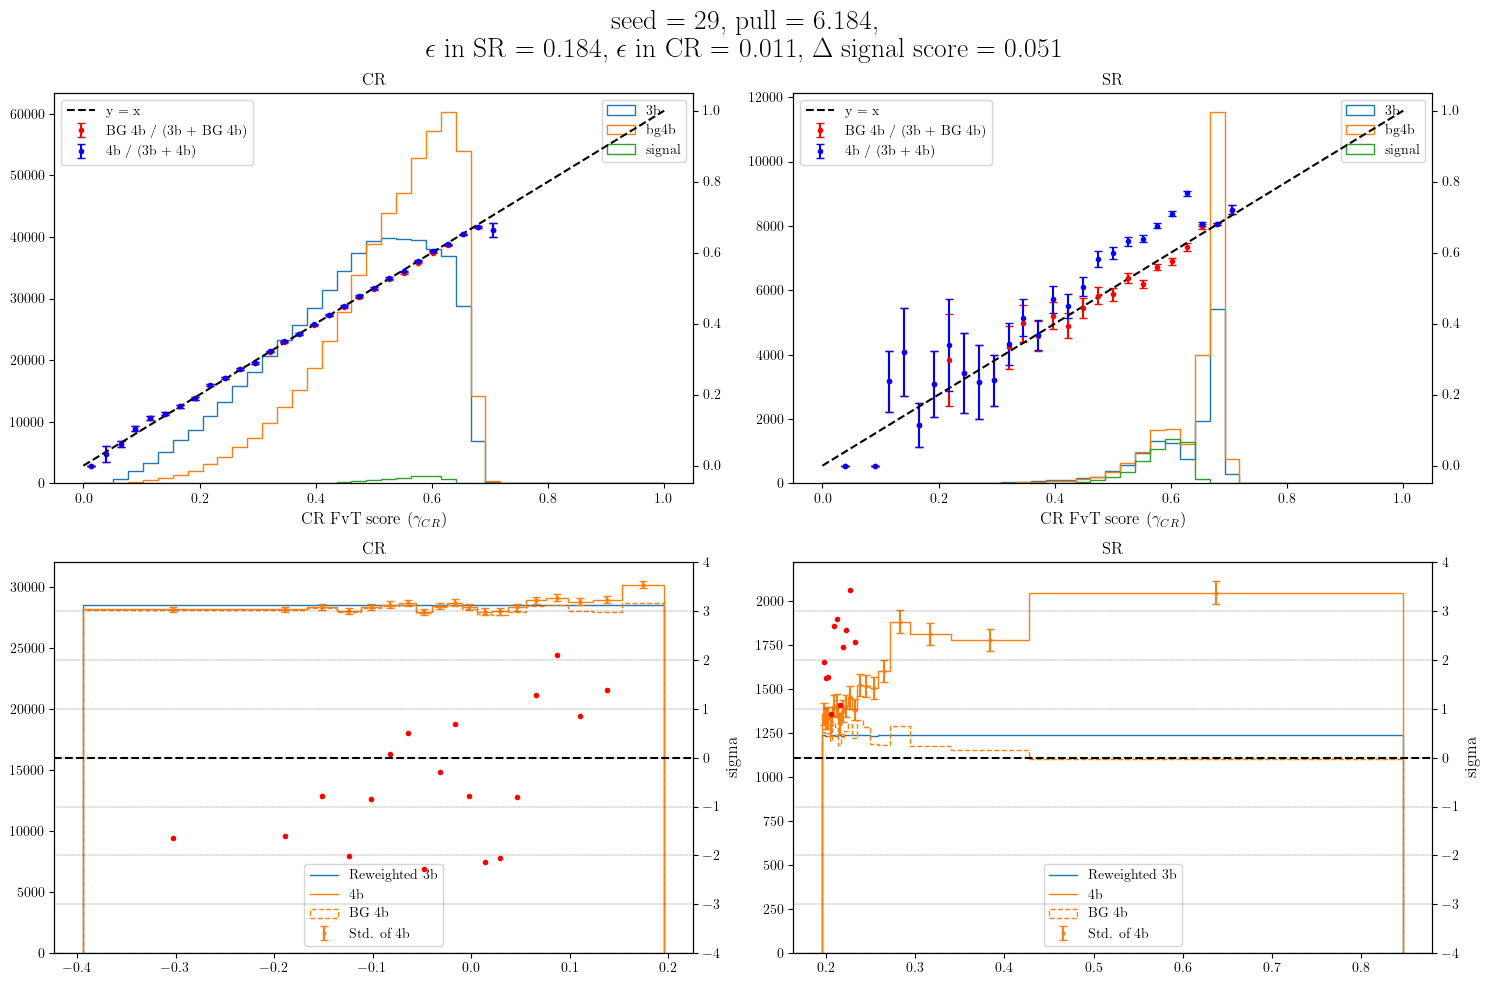

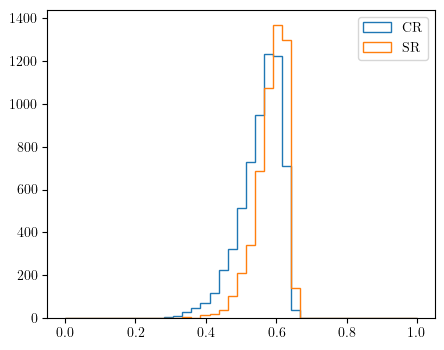

/tmp/ipykernel_313667/89886448.py:93: RuntimeWarning: invalid value encountered in divide
  ratio_bg4b = hist_bg4b / (hist_3b + hist_bg4b)
/tmp/ipykernel_313667/89886448.py:94: RuntimeWarning: invalid value encountered in divide
  ratio_4b = hist_4b / (hist_3b + hist_4b)
/tmp/ipykernel_313667/89886448.py:111: RuntimeWarning: invalid value encountered in divide
  ratio_bg4b = hist_bg4b / (hist_3b + hist_bg4b)
/tmp/ipykernel_313667/89886448.py:112: RuntimeWarning: invalid value encountered in divide
  ratio_4b = hist_4b / (hist_3b + hist_4b)


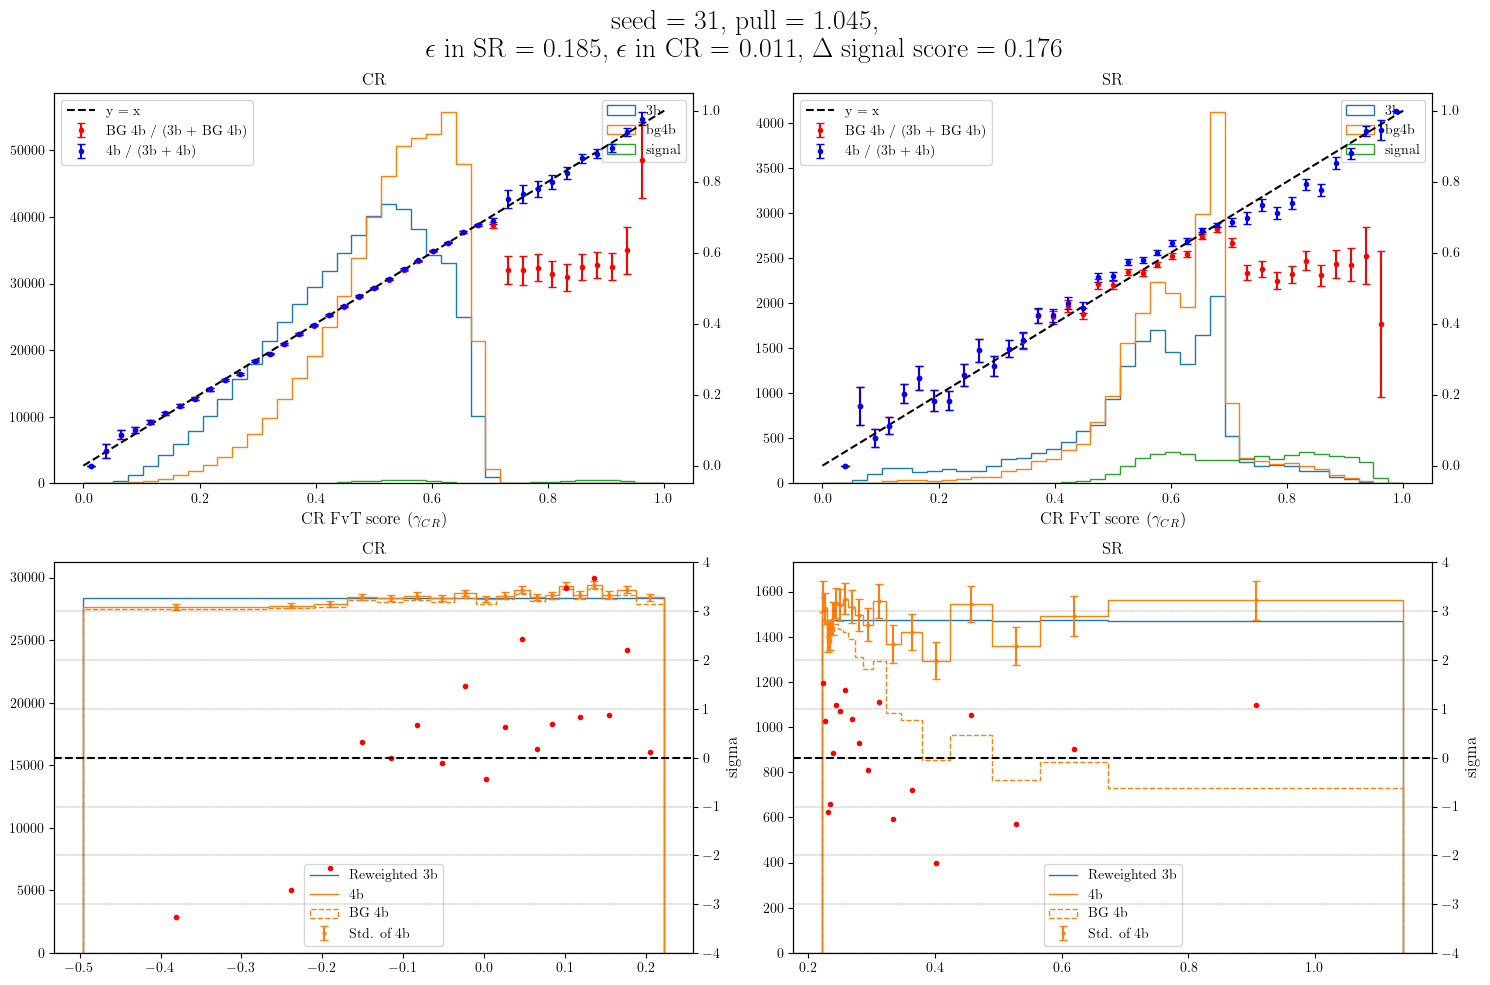

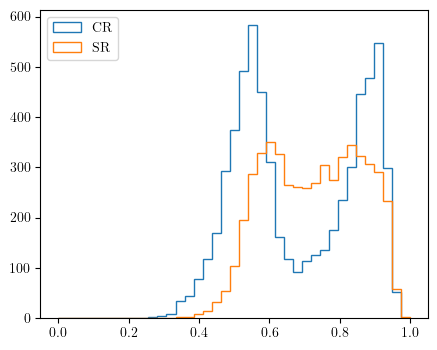

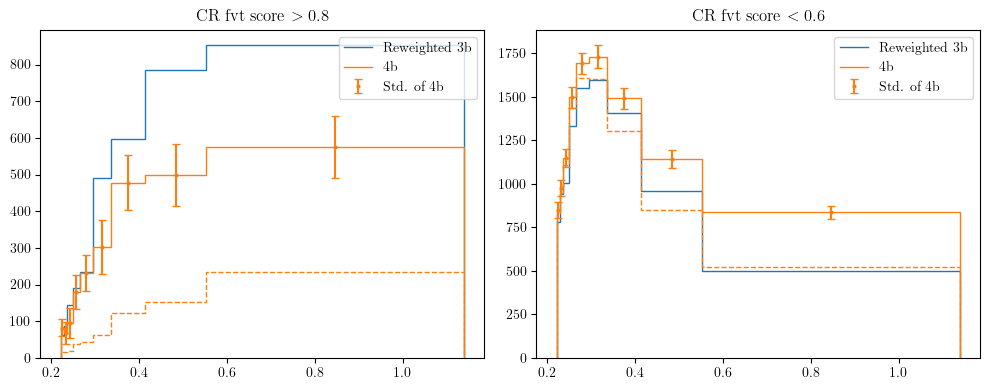

In [68]:
from events_data import get_is_signal
from signal_region import get_SR_CR_cut
from scipy import stats
from utils import get_quantiles_with_weights

signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_v2"
n_3b = 100_0000
n_test_bins = 4
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 12

signal_ratio = 0.02
sr_in_SR = np.array(signal_ratio_in_SR[signal_ratio])
mean_pull = np.sqrt(np.mean(pull_arrays_dict[(0.0, 0.0, -np.inf, np.inf)][(signal_ratio, n_test_bins)]**2, axis=1))

for seed in [29, 31]:
    hparam_filter = {
        "experiment_name": experiment_name,
        "dataset": lambda x: all([x["seed"] == seed, 
                            x["n_3b"] == n_3b, 
                            x["signal_ratio"] == signal_ratio]),
        "aux_info_step": 3, 
        "model": "FvTClassifier"
    }
    hashes = TrainingInfo.find(hparam_filter)
    assert len(hashes) == 1

    CR_fvt_tinfo = TrainingInfo.load(hashes[0])
    base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]
    base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
    smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
    smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)

    base_fvt_model = base_fvt_tinfo.load_trained_model(
        CR_fvt_tinfo.hparams["encoder_mode"]
    )
    base_fvt_model.eval()
    base_fvt_model.to(torch.device("cuda"))
    base_fvt_model: FvTClassifier

    smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
        CR_fvt_tinfo.hparams["encoder_mode"]
    )
    smeared_fvt_model.eval()
    smeared_fvt_model.to(torch.device("cuda"))
    smeared_fvt_model: AttentionClassifier

    # Use the same mother samples and exclude ones used for training base & smeared FvT model
    msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
    tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
    train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
    df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
    df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
    events_train = EventsData.from_dataframe(df_train, features)
    df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
    df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
    events_tst = EventsData.from_dataframe(df_tst, features)

    SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
    SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
    SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])

    in_SR = SR_stats > SR_cut
    in_CR = (SR_stats > CR_cut) & (SR_stats <= SR_cut)

    CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
    CR_fvt_model.eval()
    CR_fvt_model.to(torch.device("cuda"))
    CR_fvt_model: FvTClassifier

    events_tst_SR = events_tst[in_SR]
    events_tst_CR = events_tst[in_CR]
    SR_stats_CR = SR_stats[in_CR]
    SR_stats_SR = SR_stats[in_SR]

    fvt_scores_CR = CR_fvt_model.predict(events_tst_CR.X_torch)[:, 1].detach().cpu().numpy()
    signal_score_diff = np.mean(fvt_scores_CR[events_tst_CR.is_signal]) - np.mean(fvt_scores_CR[~events_tst_CR.is_signal])
    fvt_scores_SR = CR_fvt_model.predict(events_tst_SR.X_torch)[:, 1].detach().cpu().numpy()
    
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
    fig.suptitle(f"seed = {seed}, pull = {mean_pull[seed]:.3f}, \n $\epsilon$ in SR = {sr_in_SR[seed]:.3f}, $\epsilon$ in CR = {events_tst_CR.total_weight_signal / events_tst_CR.total_weight_4b:.3f}, $\Delta$ signal score = {signal_score_diff:.3f}")
    
    axs[0, 0].set_title("CR")
    axs[0, 0].set_xlabel(r"CR FvT score ($\gamma_{CR}$)")
    bins = np.linspace(0, 1, 40)    
    hist_events_by_labels(events_tst_CR, fvt_scores_CR, bins, axs[0, 0])
    hist_3b = np.histogram(fvt_scores_CR[events_tst_CR.is_3b], bins=bins, weights=events_tst_CR.weights[events_tst_CR.is_3b])[0]
    hist_bg4b = np.histogram(fvt_scores_CR[events_tst_CR.is_bg4b], bins=bins, weights=events_tst_CR.weights[events_tst_CR.is_bg4b])[0]
    hist_4b = np.histogram(fvt_scores_CR[events_tst_CR.is_4b], bins=bins, weights=events_tst_CR.weights[events_tst_CR.is_4b])[0]
    midpoints = (bins[:-1] + bins[1:]) / 2
    twinx = axs[0, 0].twinx()
    ratio_bg4b = hist_bg4b / (hist_3b + hist_bg4b)
    ratio_4b = hist_4b / (hist_3b + hist_4b)
    twinx.errorbar(midpoints, ratio_bg4b, yerr=np.sqrt(ratio_bg4b * (1 - ratio_bg4b) / (hist_3b + hist_bg4b)), 
                   fmt="o", color="red", label="BG 4b / (3b + BG 4b)", capsize=3)
    twinx.errorbar(midpoints, ratio_4b, yerr=np.sqrt(ratio_4b * (1 - ratio_4b) / (hist_3b + hist_4b)), 
                   fmt="o", color="blue", label="4b / (3b + 4b)", capsize=3)
    twinx.plot([0, 1], [0, 1], color="black", linestyle="--", label="y = x")
    twinx.legend()
    
    axs[0, 1].set_title("SR")
    axs[0, 1].set_xlabel(r"CR FvT score ($\gamma_{CR}$)")
    bins = np.linspace(0, 1, 40)
    hist_events_by_labels(events_tst_SR, fvt_scores_SR, bins, axs[0, 1])
    hist_3b = np.histogram(fvt_scores_SR[events_tst_SR.is_3b], bins=bins, weights=events_tst_SR.weights[events_tst_SR.is_3b])[0]
    hist_bg4b = np.histogram(fvt_scores_SR[events_tst_SR.is_bg4b], bins=bins, weights=events_tst_SR.weights[events_tst_SR.is_bg4b])[0]
    hist_4b = np.histogram(fvt_scores_SR[events_tst_SR.is_4b], bins=bins, weights=events_tst_SR.weights[events_tst_SR.is_4b])[0]
    midpoints = (bins[:-1] + bins[1:]) / 2
    twinx = axs[0, 1].twinx()
    ratio_bg4b = hist_bg4b / (hist_3b + hist_bg4b)
    ratio_4b = hist_4b / (hist_3b + hist_4b)
    twinx.errorbar(midpoints, ratio_bg4b, yerr=np.sqrt(ratio_bg4b * (1 - ratio_bg4b) / (hist_3b + hist_bg4b)), 
                   fmt="o", color="red", label="BG 4b / (3b + BG 4b)", capsize=3)
    twinx.errorbar(midpoints, ratio_4b, yerr=np.sqrt(ratio_4b * (1 - ratio_4b) / (hist_3b + hist_4b)), 
                   fmt="o", color="blue", label="4b / (3b + 4b)", capsize=3)
    twinx.plot([0, 1], [0, 1], color="black", linestyle="--", label="y = x")
    twinx.legend()
    
    axs[1, 0].set_title("CR")
    axs[1, 0].set_xlabel(r"SR stats log($\gamma / \tilde{\gamma}$)")
    reweights_CR = np.where(events_tst_CR.is_4b, 1, fvt_scores_CR / (1 - fvt_scores_CR))
    bins = get_quantiles_with_weights(SR_stats_CR[events_tst_CR.is_3b], 
                                      (reweights_CR * events_tst_CR.weights)[events_tst_CR.is_3b], 
                                      np.linspace(0, 1, 20))
    plot_samples_raw(events_tst_CR.is_4b, reweights_CR * events_tst_CR.weights, SR_stats_CR, axs[1, 0], bins=bins)
    axs[1, 0].hist(SR_stats_CR[events_tst_CR.is_bg4b], bins=bins, weights=events_tst_CR.weights[events_tst_CR.is_bg4b], 
                histtype="step", label="BG 4b", linestyle="--", color=plt.cm.tab10.colors[1])
    
    axs[1, 1].set_title("SR")
    axs[1, 1].set_xlabel(r"SR stats log($\gamma / \tilde{\gamma}$)")
    reweights_SR = np.where(events_tst_SR.is_4b, 1, fvt_scores_SR / (1 - fvt_scores_SR))
    bins = get_quantiles_with_weights(SR_stats_SR[events_tst_SR.is_3b], 
                                      (reweights_SR * events_tst_SR.weights)[events_tst_SR.is_3b], 
                                      np.linspace(0, 1, 20))
    plot_samples_raw(events_tst_SR.is_4b, reweights_SR * events_tst_SR.weights, SR_stats_SR, axs[1, 1], bins=bins)
    axs[1, 1].hist(SR_stats_SR[events_tst_SR.is_bg4b], bins=bins, weights=events_tst_SR.weights[events_tst_SR.is_bg4b], 
                histtype="step", label="BG 4b", linestyle="--", color=plt.cm.tab10.colors[1])
    
    for ax in axs.flatten():
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    plt.close()
    
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
    bins = np.linspace(0, 1, 40)
    ax.hist(fvt_scores_CR[events_tst_CR.is_signal], bins=bins, weights=events_tst_CR.weights[events_tst_CR.is_signal], 
            histtype="step", label="CR")
    ax.hist(fvt_scores_SR[events_tst_SR.is_signal], bins=bins, weights=events_tst_SR.weights[events_tst_SR.is_signal], 
            histtype="step", label="SR")
    ax.legend()
    plt.show()
    plt.close()
    
    if seed == 31:
        fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
        
        in_signal_dominant = fvt_scores_SR > 0.8
        ax[0].set_title(r"CR fvt score $> 0.8$")
        bins = get_quantiles_with_weights(SR_stats_SR[events_tst_SR.is_3b], 
                                      (reweights_SR * events_tst_SR.weights)[events_tst_SR.is_3b], 
                                      np.linspace(0, 1, 10))
        plot_samples_raw(events_tst_SR.is_4b[in_signal_dominant], reweights_SR[in_signal_dominant] * events_tst_SR.weights[in_signal_dominant], 
                         SR_stats_SR[in_signal_dominant], ax[0], bins=bins, disable_twin_ax=True)
        ax[0].hist(SR_stats_SR[events_tst_SR.is_bg4b & in_signal_dominant], bins=bins, 
                            weights=events_tst_SR.weights[events_tst_SR.is_bg4b & in_signal_dominant], 
                            histtype="step", label="BG 4b", linestyle="--", color=plt.cm.tab10.colors[1])
        
        is_not_signal_dominant = fvt_scores_SR < 0.6
        ax[1].set_title(r"CR fvt score $< 0.6$")
        plot_samples_raw(events_tst_SR.is_4b[is_not_signal_dominant], reweights_SR[is_not_signal_dominant] * events_tst_SR.weights[is_not_signal_dominant], 
                         SR_stats_SR[is_not_signal_dominant], ax[1], bins=bins, disable_twin_ax=True)
        ax[1].hist(SR_stats_SR[events_tst_SR.is_bg4b & is_not_signal_dominant], bins=bins, 
                            weights=events_tst_SR.weights[events_tst_SR.is_bg4b & is_not_signal_dominant], 
                            histtype="step", label="BG 4b", linestyle="--", color=plt.cm.tab10.colors[1])
        plt.tight_layout()
        plt.show()
        plt.close()
        

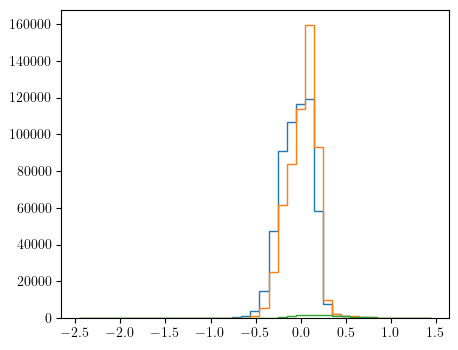

In [69]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
bins = np.linspace(np.min(SR_stats), np.max(SR_stats), 40)
hist_events_by_labels(events_tst, SR_stats, bins, ax)
plt.show()
plt.close()

In [70]:
SR_stats_dict = {}

In [71]:
import tqdm

# See if ensemble works

experiment_name = "smeared_fvt_training_ensemble"
hparam_filter = {
    "experiment_name": experiment_name,
    "dataset": lambda x: (x["seed"] == 31 and x["signal_ratio"] == 0.02),
    "model": "AttentionClassifier",
    "aux_info_step": 2,
    # "smearing": lambda x: (x["noise_scale"] == 2.0),
    
}
hashes = TrainingInfo.find(hparam_filter)

smeared_fvt_tinfo = TrainingInfo.load(hashes[0])
base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
base_fvt_model = base_fvt_tinfo.load_trained_model(smeared_fvt_tinfo.hparams["encoder_mode"])
base_fvt_model.eval()
base_fvt_model.to(torch.device("cuda"))
base_fvt_model: FvTClassifier

base_fvt_scores, base_q_repr = base_fvt_model.predict_and_representations(events_tst.X_torch)
base_fvt_scores = base_fvt_scores[:, 1].detach().cpu().numpy()
base_q_repr = base_q_repr.detach().cpu().numpy()
base_gamma = base_fvt_scores / (1 - base_fvt_scores)


for hash in tqdm.tqdm(hashes):
    done_hashes = [hash for _, _, hash in SR_stats_dict.keys()]
    if hash in done_hashes:
        continue
    smeared_fvt_tinfo = TrainingInfo.load(hash)
    seed = smeared_fvt_tinfo.hparams["smearing"]["seed"]
    noise_scale = smeared_fvt_tinfo.hparams["smearing"]["noise_scale"]
    
    base_encoder_hash = smeared_fvt_tinfo.hparams["encoder_hash"]
    base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
    smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(smeared_fvt_tinfo.hparams["encoder_mode"])
    smeared_fvt_model.eval()
    smeared_fvt_model.to(torch.device("cuda"))
    smeared_fvt_model: AttentionClassifier
    
    smeared_fvt_scores = smeared_fvt_model.predict(base_q_repr)[:, 1].detach().cpu().numpy()
    smeared_gamma = smeared_fvt_scores / (1 - smeared_fvt_scores)
    SR_stats = np.log(base_gamma / smeared_gamma)
    SR_stats_dict[(seed, noise_scale, hash)] = SR_stats


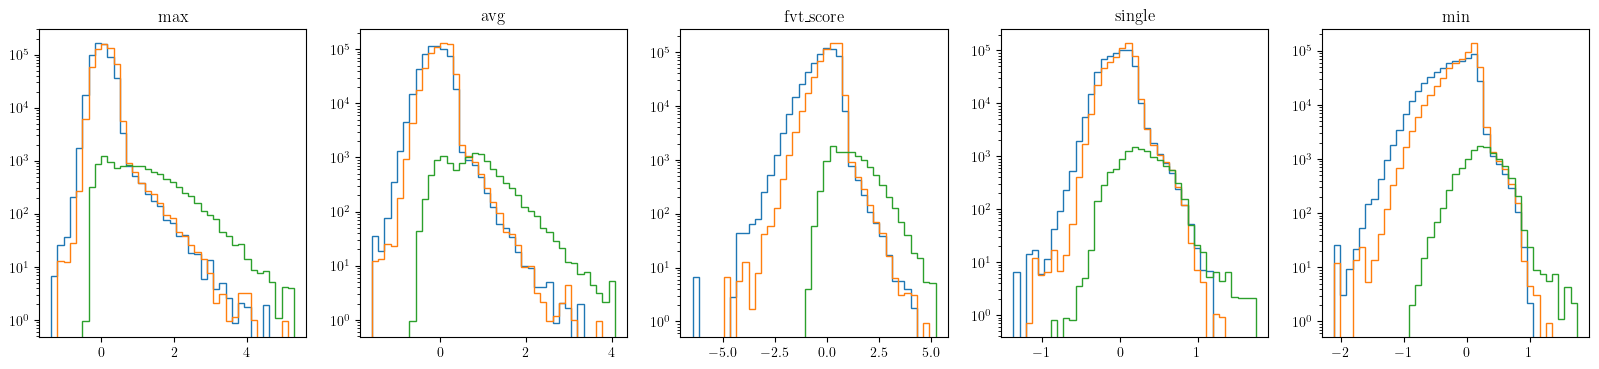

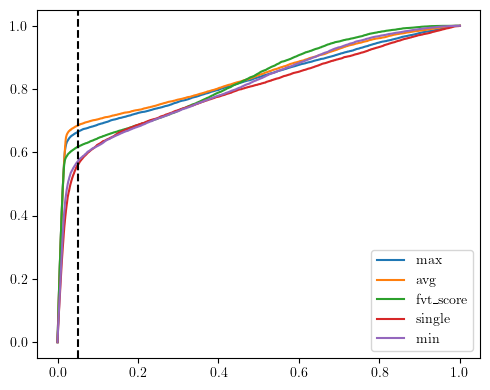

In [79]:
from plots import plot_sr_stats

# noise_scale = 1.0
SR_stats_here = [SR_stats_dict[(seed, ns, hash)] 
                 for seed, ns, hash in SR_stats_dict.keys() 
                #  if noise_scale == ns
                if seed == 0
                 ]


# SR_stats_here.append(np.log(base_gamma))
SR_stats_max = np.max(SR_stats_here, axis=0)
SR_stats_argmax = np.argmax(SR_stats_here, axis=0)
SR_stats_min = np.min(SR_stats_here, axis=0)
SR_stats_avg = np.mean(SR_stats_here, axis=0)
SR_stats_single = SR_stats_here[0]
SR_stats_fvt_score = np.log(base_gamma)

SR_stats_to_compare = [SR_stats_max, SR_stats_avg, SR_stats_fvt_score, SR_stats_single, SR_stats_min]
labels = ["max", "avg", "fvt_score", "single", "min"]

fig, axs = plt.subplots(nrows=1, ncols=len(SR_stats_to_compare), figsize=(4 * len(SR_stats_to_compare), 4))
fig2, ax2 = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))
for SR_stats, ax, label in zip(SR_stats_to_compare, axs, labels):
    bins = np.linspace(np.min(SR_stats), np.max(SR_stats), 40)
    hist_events_by_labels(events_tst, SR_stats, bins, ax)
    ax.set_title(label)
    plot_sr_stats(events_tst, SR_stats, ax2, label=label)
plt.tight_layout()
for ax in axs:
    ax.set_yscale("log")
ax2.legend()
ax2.axvline(0.05, color="black", linestyle="--")
plt.show()
plt.close()

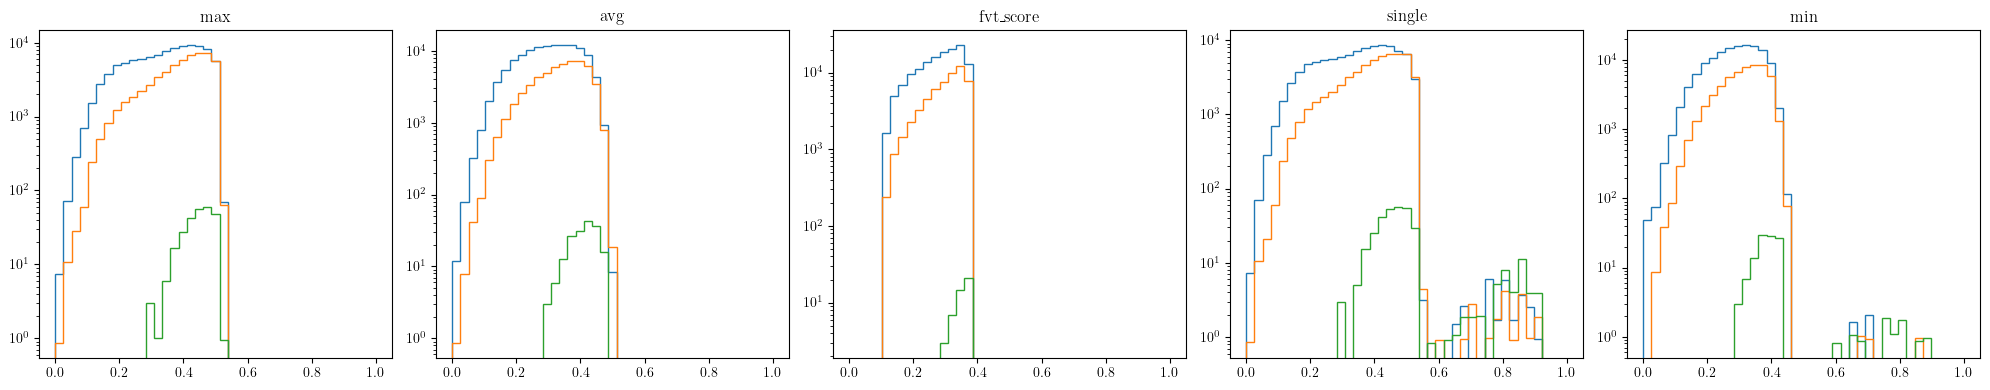

In [85]:
# print(np.corrcoef(SR_stats_max, base_fvt_scores))

# plt.plot(SR_stats_max[events_tst.is_3b], base_fvt_scores[events_tst.is_3b], "o", alpha=0.3, label="3b")
# plt.plot(SR_stats_max[events_tst.is_bg4b], base_fvt_scores[events_tst.is_bg4b], "o", alpha=0.3, label="BG 4b")
# plt.plot(SR_stats_max[events_tst.is_signal], base_fvt_scores[events_tst.is_signal], "o", alpha=0.3, label="Signal")
# plt.xlabel("SR stats max")
# plt.ylabel("Base FvT score")
# plt.legend()
# plt.show()
# plt.close()

fig, axs = plt.subplots(nrows=1, ncols=len(SR_stats_to_compare), figsize=(4 * len(SR_stats_to_compare), 4))
for SR_stats, label, ax in zip(SR_stats_to_compare, labels, axs):
    SR_cut, CR_cut = get_SR_CR_cut(SR_stats, events_tst, {"4b_in_SR": 0.9, "4b_in_CR": 0.1})
    in_SR = SR_stats > SR_cut
    in_CR = (SR_stats > CR_cut) & (SR_stats <= SR_cut)
    events_tst_CR = events_tst[in_CR]
    hist_events_by_labels(events_tst_CR, base_fvt_scores[in_CR], bins=np.linspace(0, 1, 40), ax=ax)
    ax.set_title(label)
    ax.set_yscale("log")
plt.tight_layout()
plt.show()
plt.close()


In [8]:
from signal_region import get_DRs

gamma_base_CR, gamma_smeared_CR, q_repr_base_CR = get_DRs(events_tst_CR, base_fvt_model, smeared_fvt_model, return_repr=True)
base_fvt_scores_CR = gamma_base_CR / (1 + gamma_base_CR)
smeared_fvt_scores_CR = gamma_smeared_CR / (1 + gamma_smeared_CR)
in_signal_dominant_CR = fvt_scores_CR > 0.7

gamma_base_SR, gamma_smeared_SR, q_repr_base_SR = get_DRs(events_tst_SR, base_fvt_model, smeared_fvt_model, return_repr=True)
base_fvt_scores_SR = gamma_base_SR / (1 + gamma_base_SR)
smeared_fvt_scores_SR = gamma_smeared_SR / (1 + gamma_smeared_SR)
in_signal_dominant_SR = fvt_scores_SR > 0.7

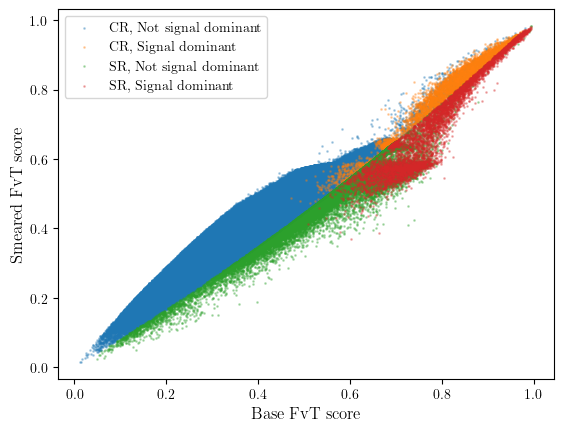

In [12]:
plt.scatter(base_fvt_scores_CR[~in_signal_dominant_CR], 
            smeared_fvt_scores_CR[~in_signal_dominant_CR], alpha=0.3, 
            s=1,
            label="CR, Not signal dominant")
plt.scatter(base_fvt_scores_CR[in_signal_dominant_CR], 
            smeared_fvt_scores_CR[in_signal_dominant_CR], alpha=0.3,
            s=1,
            label="CR, Signal dominant")

plt.scatter(base_fvt_scores_SR[~in_signal_dominant_SR], 
            smeared_fvt_scores_SR[~in_signal_dominant_SR], alpha=0.3, 
            s=1,
            label="SR, Not signal dominant")
plt.scatter(base_fvt_scores_SR[in_signal_dominant_SR], 
            smeared_fvt_scores_SR[in_signal_dominant_SR], alpha=0.3,
            s=1,
            label="SR, Signal dominant")
plt.legend(loc="upper left")
plt.ylabel("Smeared FvT score")
plt.xlabel("Base FvT score")
plt.show()
plt.close()

In [15]:
events_tst_all = EventsData.merge([events_tst_CR, events_tst_SR])
base_fvt_scores_all = np.concatenate([base_fvt_scores_CR, base_fvt_scores_SR])
smeared_fvt_scores_all = np.concatenate([smeared_fvt_scores_CR, smeared_fvt_scores_SR])
CR_fvt_scores_all = np.concatenate([fvt_scores_CR, fvt_scores_SR])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


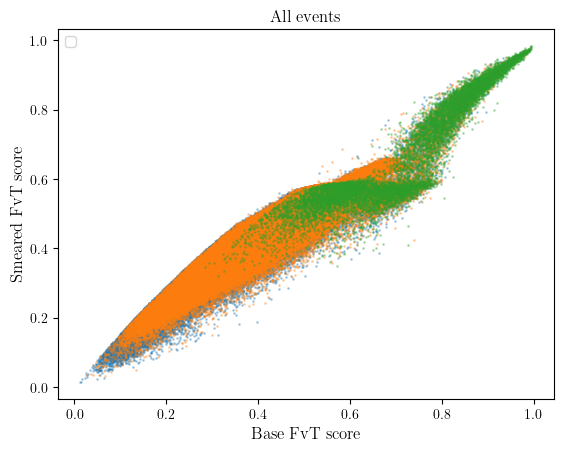

In [19]:
plt.scatter(base_fvt_scores_all[events_tst_all.is_3b], smeared_fvt_scores_all[events_tst_all.is_3b], alpha=0.3, s=1, label="3b")
plt.scatter(base_fvt_scores_all[events_tst_all.is_bg4b], smeared_fvt_scores_all[events_tst_all.is_bg4b], alpha=0.3, s=1, label="BG 4b")
plt.scatter(base_fvt_scores_all[events_tst_all.is_signal], smeared_fvt_scores_all[events_tst_all.is_signal], alpha=0.3, s=1, label="Signal")
plt.title("All events")
plt.ylabel("Smeared FvT score")
plt.xlabel("Base FvT score")
plt.legend(loc="upper left")
plt.show()
plt.close()


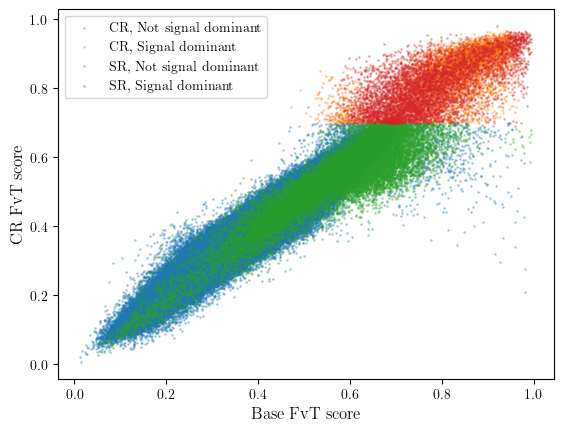

In [14]:
plt.scatter(base_fvt_scores_CR[~in_signal_dominant_CR], 
            fvt_scores_CR[~in_signal_dominant_CR], alpha=0.3, 
            s=1,
            label="CR, Not signal dominant")
plt.scatter(base_fvt_scores_CR[in_signal_dominant_CR], 
            fvt_scores_CR[in_signal_dominant_CR], alpha=0.3,
            s=1,
            label="CR, Signal dominant")

plt.scatter(base_fvt_scores_SR[~in_signal_dominant_SR], 
            fvt_scores_SR[~in_signal_dominant_SR], alpha=0.3, 
            s=1,
            label="SR, Not signal dominant")
plt.scatter(base_fvt_scores_SR[in_signal_dominant_SR], 
            fvt_scores_SR[in_signal_dominant_SR], alpha=0.3,
            s=1,
            label="SR, Signal dominant")
plt.legend(loc="upper left")
plt.xlabel("Base FvT score")
plt.ylabel("CR FvT score")
plt.show()
plt.close()

In [ ]:
plt.scatter(gamma_base_CR[~in_signal_dominant_CR][random_idx_1_CR], 
            gamma_smeared_CR[~in_signal_dominant_CR][random_idx_1_CR], alpha=0.1, 
            label="CR, Not signal dominant")
plt.scatter(gamma_base_CR[in_signal_dominant_CR][random_idx_2_CR], 
            gamma_smeared_CR[in_signal_dominant_CR][random_idx_2_CR], alpha=0.1,
            label="CR, Signal dominant")

plt.scatter(gamma_base_SR[~in_signal_dominant_SR][random_idx_1_SR], 
            gamma_smeared_SR[~in_signal_dominant_SR][random_idx_1_SR], alpha=0.1, 
            label="SR, Not signal dominant")
plt.scatter(gamma_base_SR[in_signal_dominant_SR][random_idx_2_SR], 
            gamma_smeared_SR[in_signal_dominant_SR][random_idx_2_SR], alpha=0.1,
            label="SR, Signal dominant")

plt.show()
plt.close()

50it [06:25,  7.71s/it]


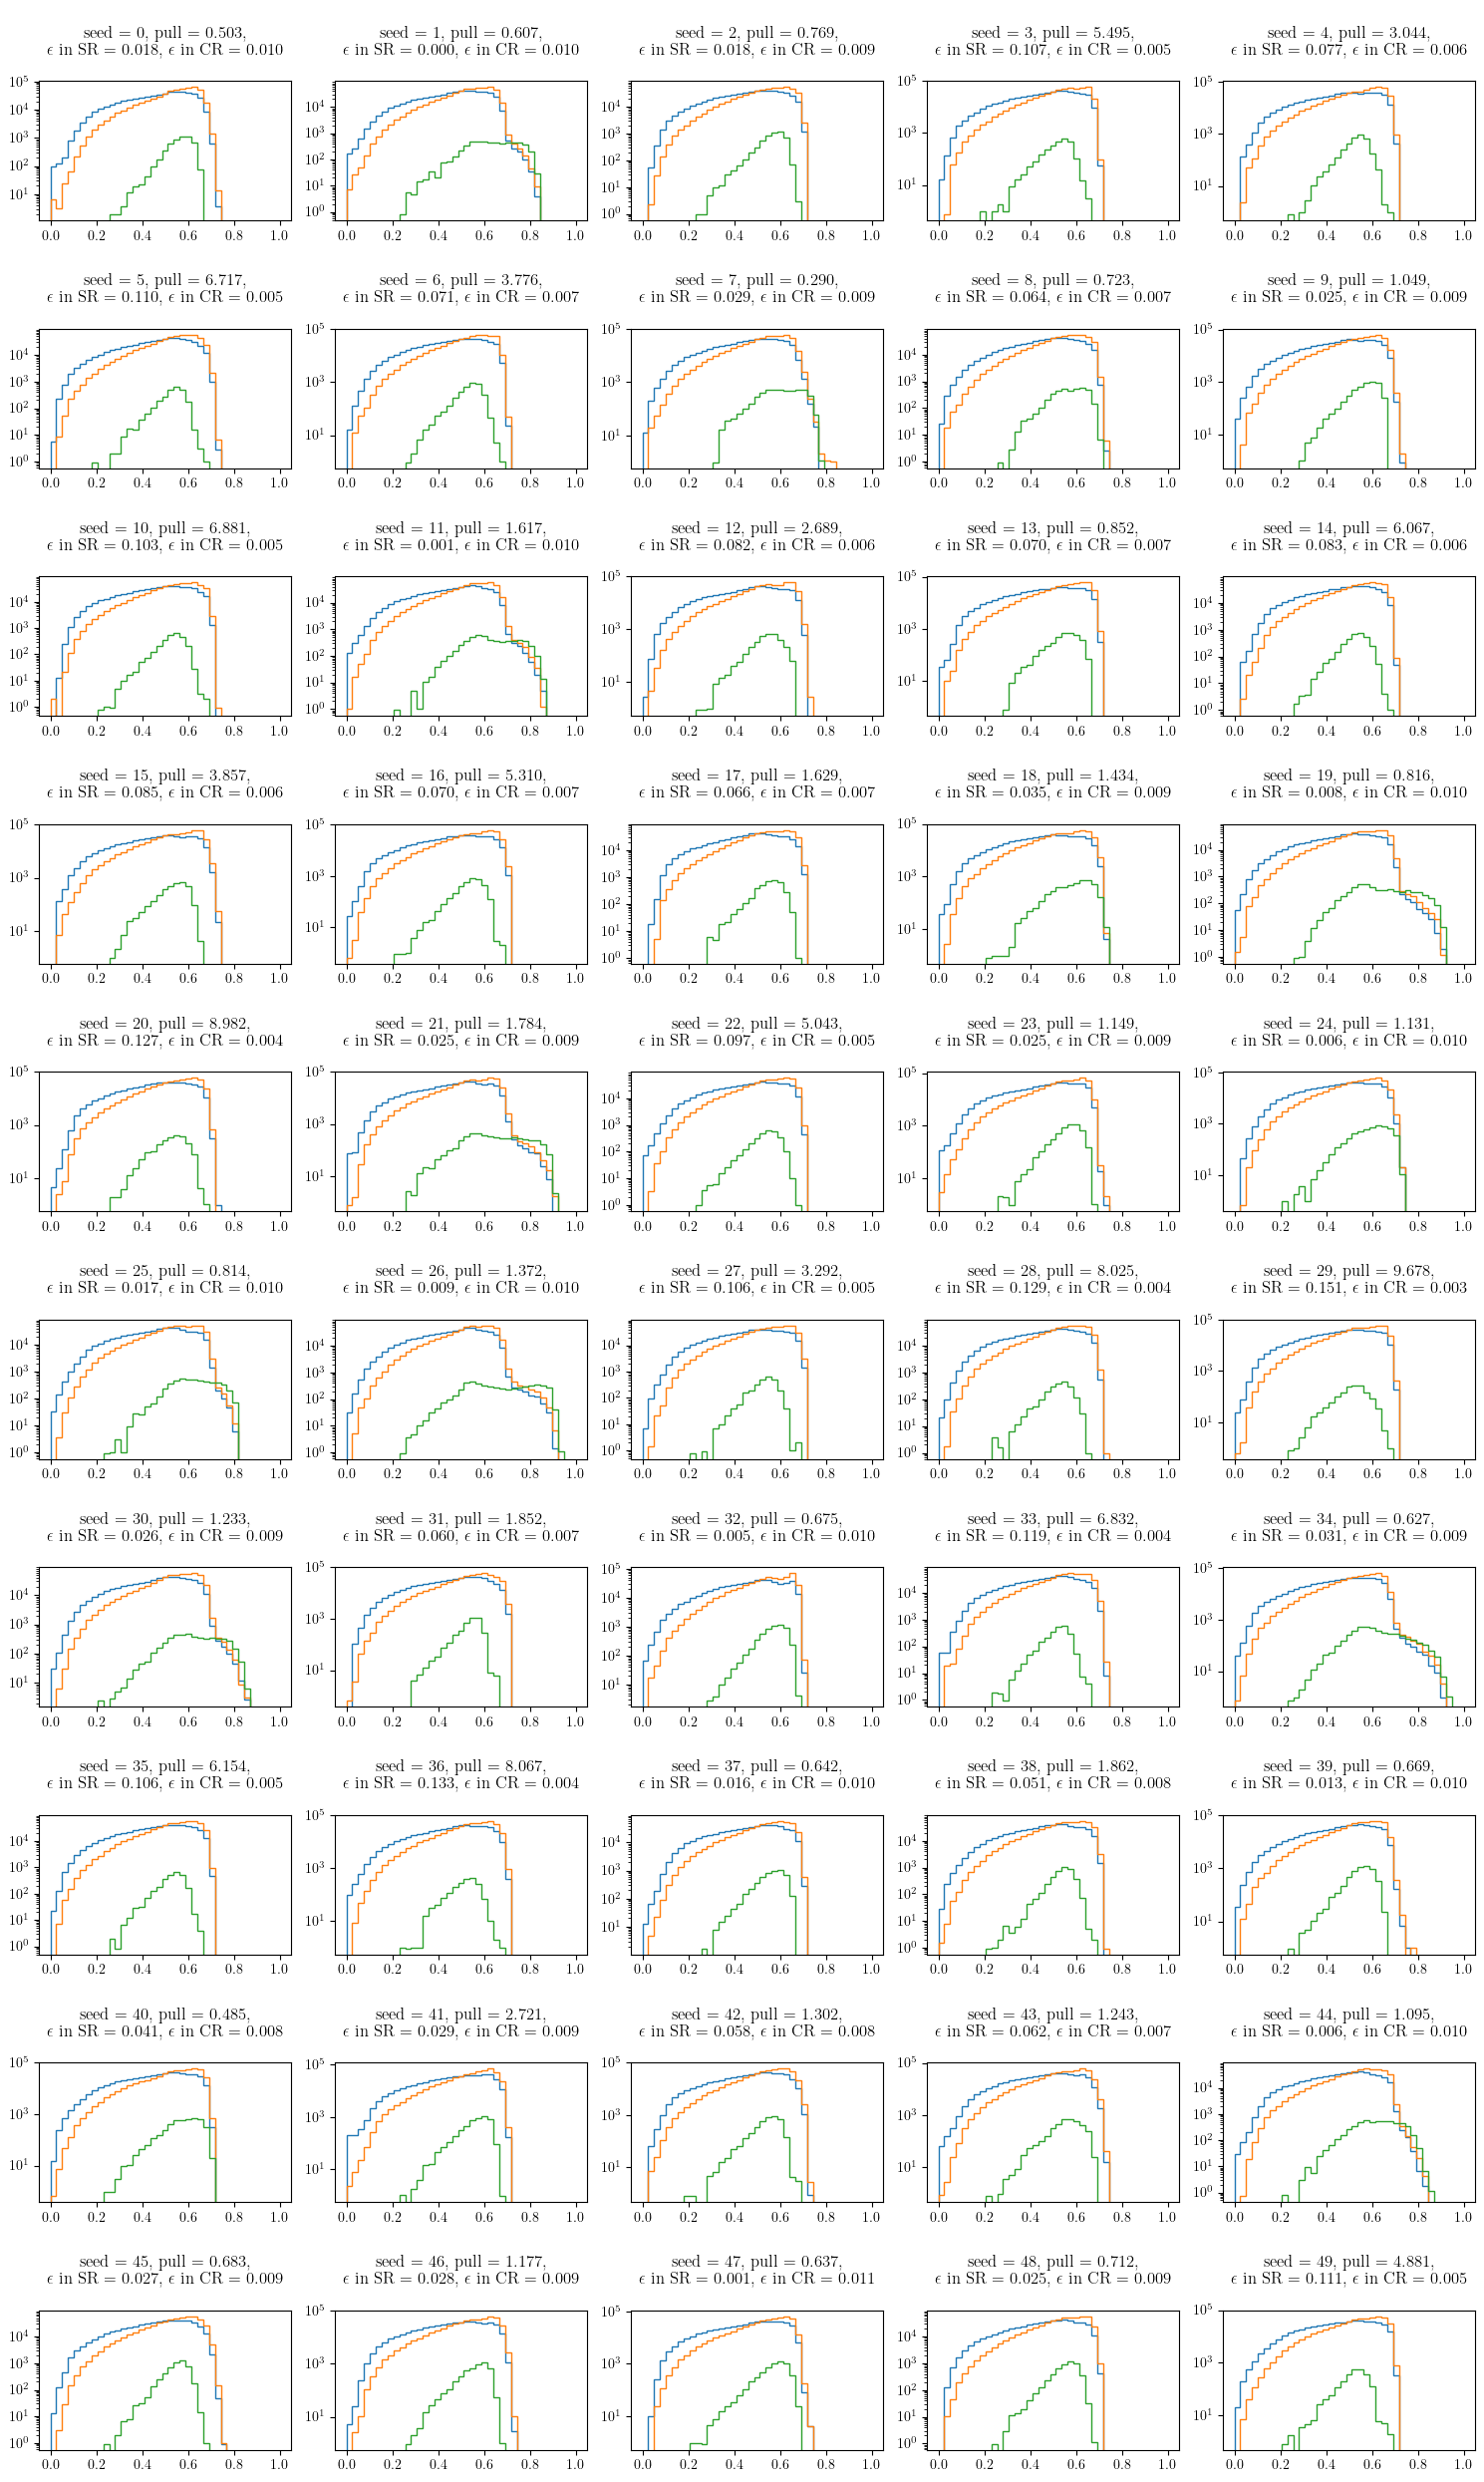

50it [06:05,  7.32s/it]


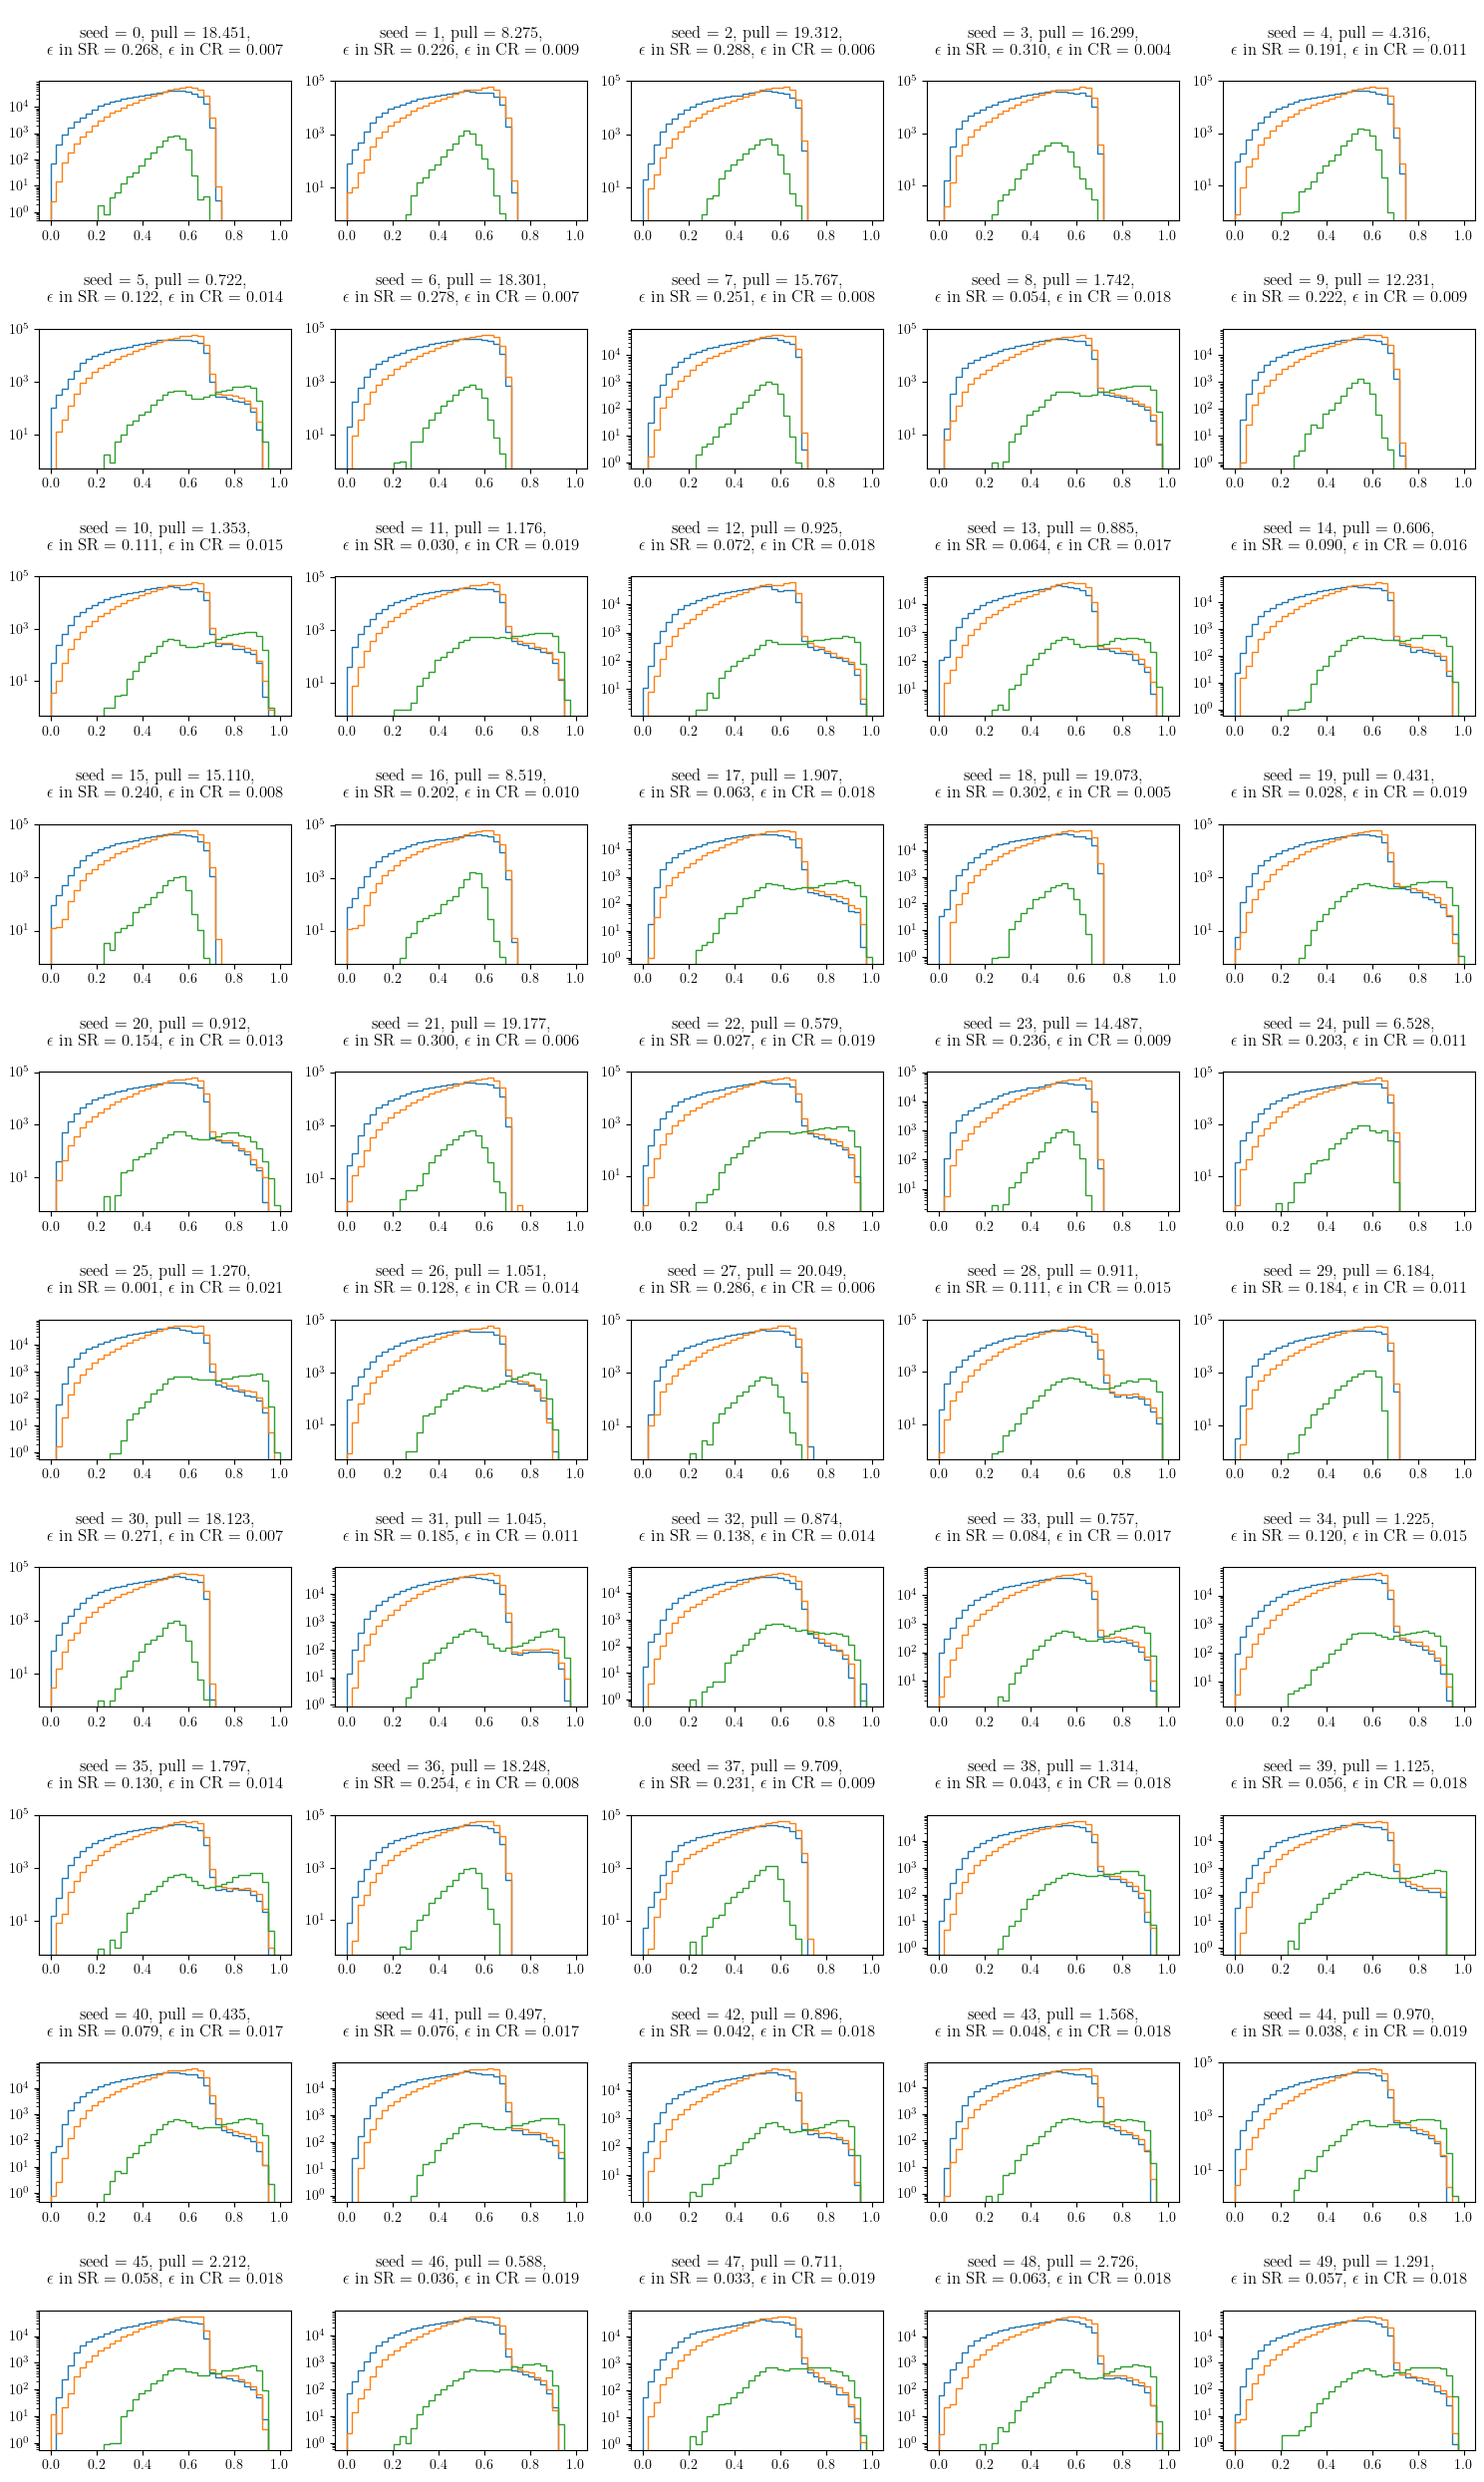

In [71]:
from events_data import get_is_signal
from signal_region import get_SR_CR_cut
from scipy import stats

signal_filename = "HH4b_picoAOD.h5"
experiment_name = "CR_fvt_training_v2"
n_3b = 100_0000
n_test_bins = 4
seeds = np.arange(50)
ncols = 5
nrows = (len(seeds) + ncols - 1) // ncols
plt.rcParams["axes.titlesize"] = 12
# signal_ratio = 0.02

signal_score_diffs_dict = {0.01: [], 0.02: []}

for signal_ratio in [0.01, 0.02]:
    sr_in_SR = np.array(signal_ratio_in_SR[signal_ratio])
    mean_pull = np.sqrt(np.mean(pull_arrays_dict[(0.0, 0.0, -np.inf, np.inf)][(signal_ratio, n_test_bins)]**2, axis=1))
    # peculiar_seeds = (mean_pull < rej_cut) & (sr_in_SR > 0.1)
    # normal_seeds = ~peculiar_seeds
    # peculiar_seeds = np.arange(50)[peculiar_seeds]
    # normal_seeds = np.arange(50)[normal_seeds]
    # normal_seeds = np.random.choice(normal_seeds, size=len(peculiar_seeds), replace=False)

    # plot_seeds = {"peculiar": peculiar_seeds, "normal": normal_seeds}

    # for seed_type, seeds in plot_seeds.items():
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(3 * ncols, 2.5 * nrows))
    # fig.suptitle(f"{seed_type} seeds")
    for i, seed in tqdm.tqdm(enumerate(seeds)):
        hparam_filter = {
            "experiment_name": experiment_name,
            "dataset": lambda x: all([x["seed"] == seed, 
                                x["n_3b"] == n_3b, 
                                x["signal_ratio"] == signal_ratio]),
            "aux_info_step": 3, 
            "model": "FvTClassifier"
        }
        hashes = TrainingInfo.find(hparam_filter)
        assert len(hashes) == 1
        
        CR_fvt_tinfo = TrainingInfo.load(hashes[0])
        base_encoder_hash = CR_fvt_tinfo.hparams["encoder_hash"]
        base_fvt_tinfo = TrainingInfo.load(base_encoder_hash)
        smeared_fvt_hash = CR_fvt_tinfo.hparams["smeared_fvt_hash"]
        smeared_fvt_tinfo = TrainingInfo.load(smeared_fvt_hash)

        base_fvt_model = base_fvt_tinfo.load_trained_model(
            CR_fvt_tinfo.hparams["encoder_mode"]
        )
        base_fvt_model.eval()
        base_fvt_model.to(torch.device("cuda"))
        base_fvt_model: FvTClassifier

        smeared_fvt_model = smeared_fvt_tinfo.load_trained_model(
            CR_fvt_tinfo.hparams["encoder_mode"]
        )
        smeared_fvt_model.eval()
        smeared_fvt_model.to(torch.device("cuda"))
        smeared_fvt_model: AttentionClassifier

        # Use the same mother samples and exclude ones used for training base & smeared FvT model
        msamples = MotherSamples.load(smeared_fvt_tinfo.ms_hash)
        tst_scdinfo = msamples.scdinfo[~smeared_fvt_tinfo.ms_idx]
        train_scdinfo = msamples.scdinfo[smeared_fvt_tinfo.ms_idx]
        df_train = train_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_train["signal"] = get_is_signal(train_scdinfo, signal_filename)
        events_train = EventsData.from_dataframe(df_train, features)
        df_tst = tst_scdinfo.fetch_data_with_loaded_df(raw_df_list)
        df_tst["signal"] = get_is_signal(tst_scdinfo, signal_filename)
        events_tst = EventsData.from_dataframe(df_tst, features)
        
        SR_stats = smeared_fvt_tinfo.aux_info["SR_stats_tst"]
        SR_stats_train = smeared_fvt_tinfo.aux_info["SR_stats_train"]
        SR_cut, CR_cut = get_SR_CR_cut(SR_stats_train, events_train, CR_fvt_tinfo.hparams["signal_region"])
        
        in_SR = SR_stats > SR_cut
        in_CR = (SR_stats > CR_cut) & (SR_stats <= SR_cut)
        
        CR_fvt_model = CR_fvt_tinfo.load_trained_model("best")
        CR_fvt_model.eval()
        CR_fvt_model.to(torch.device("cuda"))
        CR_fvt_model: FvTClassifier
        
        events_tst_SR = events_tst[in_SR]
        events_tst_CR = events_tst[in_CR]
        
        fvt_scores_CR = CR_fvt_model.predict(events_tst_CR.X_torch)[:, 1].detach().cpu().numpy()
        ax = axs[i // ncols, i % ncols]
        ax.set_title(
rf"""
seed = {seed}, pull = {mean_pull[seed]:.3f},
$\epsilon$ in SR = {sr_in_SR[seed]:.3f}, $\epsilon$ in CR = {events_tst_CR.total_weight_signal / events_tst_CR.total_weight_4b:.3f}
"""
        )
        hist_events_by_labels(events_tst_CR, fvt_scores_CR, np.linspace(0, 1, 40), ax)
        ax.set_yscale("log")
        signal_score_diff = np.mean(fvt_scores_CR[events_tst_CR.is_signal]) - np.mean(fvt_scores_CR[~events_tst_CR.is_signal])
        signal_score_diffs_dict[signal_ratio].append(signal_score_diff)
    
    plt.tight_layout()
    plt.savefig(f"data/plots/fvt_scores_CR_plots_{experiment_name}_signal_ratio={signal_ratio}_n_test_bins={n_test_bins}_logscale.pdf", dpi=300)
    plt.show()
    plt.close()

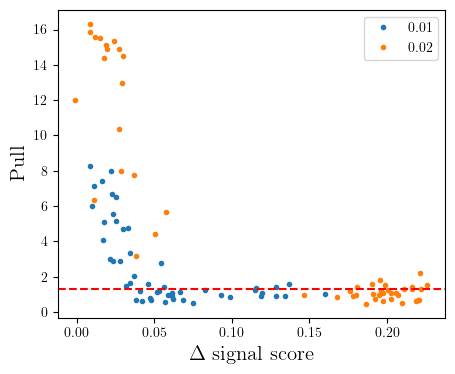

In [27]:
from scipy import stats

n_test_bins = 8
signal_ratio = 0.01

sig_level = 0.05
rej_cut = stats.chi2.ppf(1 - sig_level, df=n_test_bins - 1)
rej_cut = np.sqrt(rej_cut / n_test_bins)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 4))    
for signal_ratio in [0.01, 0.02]:
    sr_in_SR = signal_ratio_in_SR[signal_ratio]
    mean_pull = np.sqrt(np.mean(pull_arrays_dict[(0.0, 0.0, -np.inf, np.inf)][(signal_ratio, n_test_bins)]**2, axis=1))
    mean_pull_bfc = np.sqrt(np.mean(pull_arrays_before_correction[(signal_ratio, n_test_bins)]**2, axis=1))
    signal_score_diffs = signal_score_diffs_dict[signal_ratio]
    
    # ax.plot(sr_in_SR, mean_pull, "o", label=f"{signal_ratio} (after correction)")
    # ax.plot(sr_in_SR, mean_pull_bfc, "o", label=f"{signal_ratio} (before correction)")
    ax.plot(signal_score_diffs, mean_pull, "o", label=f"{signal_ratio}")
ax.axhline(rej_cut, color="red", linestyle="--")
ax.legend()
# ax.set_xlabel("Signal ratio in SR")
ax.set_xlabel("$\Delta$ signal score")
ax.set_ylabel("Pull")
plt.show()
